## Table of Contents

- [1. Tutorial on convolutional graph neural networks](#1-tutorial-on-convolutional-graph-neural-networks)
  - [1.1 References](#11-references)
  - [1.2 Learning Goals and Roadmap](#12-learning-goals-and-roadmap)
  - [1.3 Background Assumptions](#13-background-assumptions)
- [2. Aggregation](#2-aggregation)
  - [2.1 Eigenvector Centrality as Aggregation](#21-eigenvector-centrality-as-aggregation)
  - [2.2 Eigenvector Centrality for the Pinwheel Network](#22-eigenvector-centrality-for-the-pinwheel-network)
  - [2.3 Random Walk Centrality on Pinwheel Graph](#23-random-walk-centrality-on-pinwheel-graph)
  - [2.4 Aggregation in the DeepWalk Algorithm](#24-aggregation-in-the-deepwalk-algorithm)
- [3. Aggregation in GCNs](#3-aggregation-in-gcns)
  - [3.1 What Does Each Node Do?](#31-what-does-each-node-do)
  - [3.2 How Do Messages Propagate Across the Network?](#32-how-do-messages-propagate-across-the-network)
  - [3.3 GCN Aggregation](#33-gcn-aggregation)
    - [3.3.1 Step 1: Choose Neighbors](#331-step-1-choose-neighbors)
    - [3.3.2 Step 2: Receive messages](#332-step-2-receive-messages)
    - [3.3.3 Step 3: Aggregate Messages](#333-step-3-aggregate-messages)
    - [3.3.4 Fixing a Problem with Step 3](#334-fixing-a-problem-with-step-3)
    - [3.3.5 Fixing Another Problem with Step 3: One-Sided Normalization](#335-fixing-another-problem-with-step-3-one-sided-normalization)
    - [3.3.6 An Aside: Similar Matrix Patterns, Different Objects](#336-an-aside-similar-matrix-patterns-different-objects)
    - [3.3.7 Aside: Why call it "convolutional"?](#337-aside-why-call-it-convolutional)
- [4. Transforming the Aggregated Signal](#4-transforming-the-aggregated-signal)
  - [4.1 Two Core Steps](#41-two-core-steps)
  - [4.2 Transformation Step 1 -- Weighting](#42-transformation-step-1-weighting)
    - [4.2.1 Choosing the Dimension of $W$](#421-choosing-the-dimension-of-w)
  - [4.2.2 Aside: Checking the dimensions of the matrices](#422-aside-checking-the-dimensions-of-the-matrices)
  - [4.3 Segue: Adding layers to the Network](#43-segue-adding-layers-to-the-network)
    - [4.3.1 The Trade-Off: Depth vs. Over-Smoothing](#431-the-trade-off-depth-vs-over-smoothing)
  - [4.3.2 Notation for aggregating layers](#432-notation-for-aggregating-layers)
  - [4.4 Transformation Step 2: Activation](#44-transformation-step-2-activation)
    - [4.4.1 Choosing hidden-layer activations: what these terms mean](#441-choosing-hidden-layer-activations-what-these-terms-mean)
    - [4.4.2 Example: compare ReLU, tanh, and sigmoid on the same weighted output](#442-example-compare-relu-tanh-and-sigmoid-on-the-same-weighted-output)
- [5. Designing Hidden Layers and the Output Layer](#5-designing-hidden-layers-and-the-output-layer)
  - [5.1 Depth and Width: Choosing the Numbers and Dimensions of Hidden Layers](#51-depth-and-width-choosing-the-numbers-and-dimensions-of-hidden-layers)
    - [5.1.1 Depth: Choosing the Number of Hidden Layers](#511-depth-choosing-the-number-of-hidden-layers)
    - [5.1.2 Width: Choosing Hidden-Layer Dimensions](#512-width-choosing-hidden-layer-dimensions)
    - [5.1.3 Example: What changes when depth and width change?](#513-example-what-changes-when-depth-and-width-change)
  - [5.2 Choosing an Output Function](#52-choosing-an-output-function)
    - [5.2.1 Common Output Functions](#521-common-output-functions)
    - [5.2.2 Steps for Training GCN](#522-steps-for-training-gcn)
- [6. "Real-world" Example](#6-real-world-example)
  - [6.1 What Data Do We Have](#61-what-data-do-we-have)
  - [6.2 Encoding Story Descriptions as Feature Vectors](#62-encoding-story-descriptions-as-feature-vectors)
  - [6.3 Build the Pinwheel Graph and Assign Story Labels](#63-build-the-pinwheel-graph-and-assign-story-labels)
  - [6.4 Attach Feature Vectors to the Networkx Representation of Nodes](#64-attach-feature-vectors-to-the-networkx-representation-of-nodes)
- [7. Evaluating the Nodes Graph and Implementing a GCN](#7-evaluating-the-nodes-graph-and-implementing-a-gcn)
  - [7.1 Understanding and Using Tensors in PyTorch](#71-understanding-and-using-tensors-in-pytorch)
  - [7.2 Understanding PyTorch Geometric (PyG) Objects](#72-understanding-pytorch-geometric-pyg-objects)
    - [7.2.1 Storing the Graph in the PyG Object](#721-storing-the-graph-in-the-pyg-object)
    - [7.2.2 Storing Node Features in `data.x`](#722-storing-node-features-in-datax)
  - [7.3 The Building Blocks of a GCN](#73-the-building-blocks-of-a-gcn)
    - [7.3.1 Specifying the Architecture in `__init__`](#731-specifying-the-architecture-in-init)
    - [7.3.2 What the Forward Pass Does](#732-what-the-forward-pass-does)
    - [7.3.3 Running the Model Without Training](#733-running-the-model-without-training)
- [8. Using the Embedding to Partition Nodes](#8-using-the-embedding-to-partition-nodes)
  - [8.1 Visualize the Embeddings with t-SNE](#81-visualize-the-embeddings-with-t-sne)
  - [8.2 Find Clusters with K-Means](#82-find-clusters-with-k-means)
  - [8.3 Why This Worked Without Training](#83-why-this-worked-without-training)

This table of contents lists the numbered sections, subsections, and subsubsections that structure the notebook.

### 1. Tutorial on convolutional graph neural networks

#### 1.1 References
This tutorial is constructed from 
 - A [google collab tutorial](https://colab.research.google.com/drive/1h3-vJGRVloF5zStxL5I0rSy4ZUPNsjy8?usp=sharing#scrollTo=NgcpV4rjAWy-) on graph neural networks.
 - A [second collab tutorial](https://colab.research.google.com/drive/14OvFnAXggxB8vM4e8vSURUp1TaKnovzX) on node classification using graph neural networks 
 - _Hands-On Graph Neural Networks Using Python_ Maxime Labonne, chapter 6
 - Lectures 6.1-6.4 from [Stanford machine learning course](https://www.youtube.com/watch?v=MH4yvtgAR-4)
 - A variety of other sources including copilot and ChatGPT

#### 1.2 Learning Goals and Roadmap

By the end of this tutorial, you should be able to:
- explain aggregation as a unifying idea across centrality, random walks, DeepWalk/Node2Vec, and GCNs,
- distinguish message type from aggregation scope (local vs global),
- interpret a GCN layer as local, layered feature aggregation with learnable weights,
- train and evaluate a basic GCN for node classification,
- connect GCN behavior to concepts you already know from network analysis.

Roadmap for this notebook:
1. Revisit familiar graph methods through the lens of aggregation.
2. Transition from scalar/probability aggregation to feature-vector aggregation.
3. Write the GCN update rule as a matrix aggregation step.
4. Implement, train, and evaluate a simple GCN model.
5. Interpret results and discuss limits and practical caveats.

#### 1.3 Background Assumptions

The tutorial assumes that some of you are completely unfamiliar with neural networks, but the tutorial tries to make some connections for those that have used them. 


---

### 2. Aggregation

In this section, we frame GCNs as one more aggregation method in a sequence you already know from network analysis.

| Method | Message Type | Aggregation Scope |
| --- | --- | --- |
| Eigenvector | Centrality scores | Global |
| Random Walk | Probability flow | Global |
| DeepWalk/Node2Vec | Walk co-occurrence | Local (windowed) |
| GNNs | Feature vectors | Local (layered) |

This perspective emphasizes **message-aggregation**: each method defines a message, chooses a neighborhood/context, and aggregates repeatedly to produce a representation. GCNs are the same pattern, except the messages are feature vectors and the aggregation is performed layer-by-layer with learned transformations.

Some sources introduce GCNs by contrasting them with image CNNs, including the Stanford ML course linked above. That is a useful perspective, but for this tutorial we will use the aggregation viewpoint because you are seeing GCNs for the first time from a network analysis background.

---


#### 2.1 Eigenvector Centrality as Aggregation

We start with eigenvector centrality because it is a familiar example of aggregation. Each node receives scalar messages (centrality values) from its neighbors, aggregates those messages by summing, and repeats this process until the values stabilize into a global ranking.

Formally, we let $x_i^{(t)}$ denote node $i$'s centrality value at update step $t$. A simple aggregation update is

$$
x_i^{(t+1)} = \sum_{j=1}^n A_{ij}x_j^{(t)}.
$$

In vector form,

$$
\mathbf{x}^{(t+1)} = A\mathbf{x}^{(t)}.
$$

At equilibrium (up to scaling), the update no longer changes direction, so

$$
\mathbf{x}^{(t+1)} = \lambda \mathbf{x}^{(t)}.
$$

Substitute this into the update equation to get the eigenvector formulation:

$$
A\mathbf{x} = \lambda\mathbf{x}.
$$

We use the eigenvector associated with the largest eigenvalue (principal eigenvector), which yields positive entries for connected graphs.


#### 2.2 Eigenvector Centrality for the Pinwheel Network

Consider the pinwheel graph.

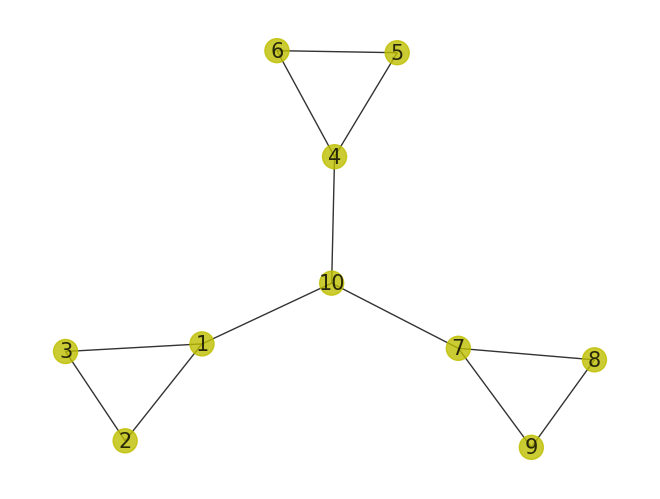

In [1]:
import networkx as nx
from matplotlib import pyplot as plt
pinwheel_graph = nx.Graph()
pinwheel_graph.add_nodes_from([1,2,3,4,5,6,7,8,9,10])
pinwheel_graph.add_edges_from([(1,2),(1,3),(2,3),(4,5),(4,6),(5,6),(7,8),(7,9),(8,9),(1,10),(4,10),(7,10)])
colormap = []
[colormap.append('y') for nodes in pinwheel_graph.nodes()]
#pos = nx.nx_agraph.graphviz_layout(G,prog='neato')
pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato")
plt.figure(1)
plt.clf()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)

On the pinwheel graph, eigenvector centrality is not just counting how many neighbors a node has. A node gets a high score when it is connected to neighbors that also receive high scores.

That is why the hub node ends up with the largest value: it aggregates centrality from the three bridge nodes, and each bridge node also aggregates centrality from its own triangle. Repeating the local update over and over pushes information farther through the graph, so the final centrality score reflects global structure rather than only immediate degree.

This gives us a useful template for the rest of the notebook:
- local rule: each node aggregates messages from neighbors,
- repeated updates: those messages propagate through the network,
- global outcome: the final value captures larger-scale graph structure.

Similar aggregation patterns appear in random walk centrality, DeepWalk, and then GCNs, but the type of message and the scope of message passing will change.

Let's examine eigenvector centrality for concreteness.

In [2]:
import numpy as np
A = nx.linalg.adjacency_matrix(pinwheel_graph).toarray()
eigvals, eigvecs = np.linalg.eig(A)
eigvals = [0 if np.abs(val) < 1e-5 else val for val in eigvals] # Manage roundoff error
print(f"eigenvectors are {np.round(eigvals,2)}")

eigenvectors are [-2.09 -1.    2.51  2.    0.57  2.   -1.   -1.   -1.   -1.  ]


Find the eigenvalue with the highest value and extract the corresponding eigenvector. The values in that principal eigenvector are all positive. The values of the principal eigenvector are the eigenector centrality values.

In [3]:
def get_principal_eigenvector(eigvals, eigvecs):
    """Return the eigenvector associated with the eigenvalue of largest modulus."""
    max_modulus, max_index = 0, 0
    for i in range(len(eigvals)):
        if abs(eigvals[i]) > max_modulus:
            max_modulus = abs(eigvals[i])
            max_index = i
    return eigvecs[:, max_index]

x = get_principal_eigenvector(eigvals, eigvecs)
print(f"the principal eigenvector is {x}")

the principal eigenvector is [0.37686362 0.24889665 0.24889665 0.37686362 0.24889665 0.24889665
 0.37686362 0.24889665 0.24889665 0.44969343]


Plot the centralities for reference.

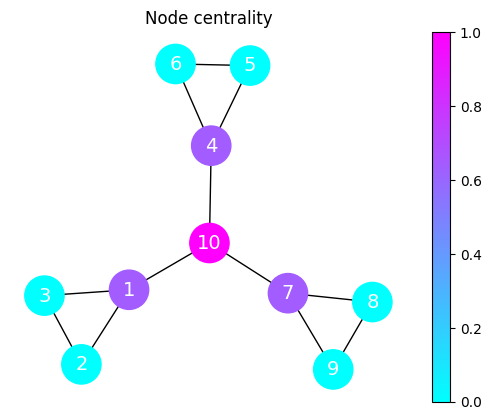

In [4]:
def draw_graph_by_node_centrality(G,pos,centrality, title="Node centrality"):
    # Color a node by it's random walk distance from node zero
    plt.axis('off')
    _ = plt.title(title)
    nx.draw_networkx(G, 
                    pos=pos, 
                    node_color=centrality,
                    node_size=800,
                    cmap='cool',
                    font_size=14,
                    font_color='white')
    sm = plt.cm.ScalarMappable(cmap = 'cool',norm=plt.Normalize(vmin = 0, vmax=1))
    _ = plt.colorbar(sm, ax=plt.gca())
draw_graph_by_node_centrality(pinwheel_graph,pos,x)

The figure shows that node 10 has the highest eigenvector centrality. This is because node 10 "receives" centrality from its neighbors (nodes 1, 4, and 7), who in turn "receive" centrality from their neighbors. We can think of this using a message passing metaphor. 
 - Each node receives messages from its neighbors
 - Each node sums up the messages from its neighbors to form a new message
 - Each node sends this message to its neighbors

After all the messages have been passed, computed, passed again, and so on, everyone reaches a point where the message they compute is exactly the same as what they computed on the previous round of message-passing. The message computed by each agent is the eigenvector centrality. 

We'll see the message-passing metaphor in graph neural networks.

#### 2.3 Random Walk Centrality on Pinwheel Graph

For random walk centrality, the message is probability mass. Each node sends its current probability mass across outgoing edges, and the graph aggregates those incoming probabilities. In matrix form, if $P=D^{-1}A$ is the random-walk transition matrix and $\mathbf{p}^{(t)}$ is a row vector of node probabilities at step $t$, then

$$
\mathbf{p}^{(t+1)} = \mathbf{p}^{(t)}P.
$$

Repeated updates spread probability through the network until the distribution stabilizes.

random walk centrality: {1: np.float64(0.12455879788582128), 2: np.float64(0.08345302548689229), 3: np.float64(0.08345302548689229), 4: np.float64(0.12455879788582128), 5: np.float64(0.08345302548689229), 6: np.float64(0.08345302548689229), 7: np.float64(0.12455879788582128), 8: np.float64(0.08345302548689229), 9: np.float64(0.08345302548689229), 10: np.float64(0.12560545342118207)}


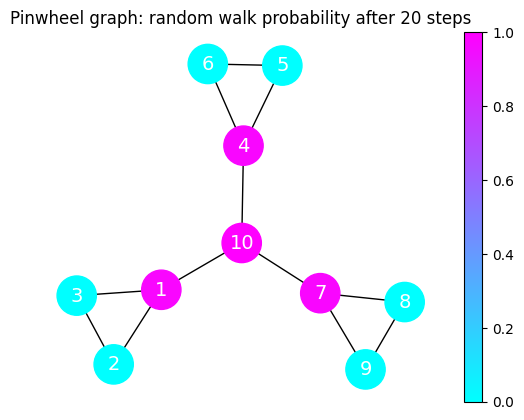

In [5]:
node_order = list(pinwheel_graph.nodes())
A_rw = nx.linalg.adjacency_matrix(pinwheel_graph, nodelist=node_order).toarray()
D_rw = np.diag(A_rw.sum(axis=1))
P = np.linalg.inv(D_rw) @ A_rw

# Start the walk at node 10, the hub of the pinwheel graph.
p = np.zeros(len(node_order))
p[node_order.index(10)] = 1.0

for _ in range(20):
    p = p @ P

random_walk_centrality = {
    node_order[i]: p[i] for i in range(len(node_order))
}
print(f"random walk centrality: {random_walk_centrality}")

draw_graph_by_node_centrality(
    pinwheel_graph,
    pos,
    p,
    title="Pinwheel graph: random walk probability after 20 steps"
)

Very briefly, this shows the same aggregation pattern as eigenvector centrality but with a different message. Instead of sending scalar importance scores, nodes send probability mass. After enough updates, the mass concentrates on nodes that are easier to revisit in the walk. On this graph, the hub and bridge nodes attract more probability than the outer nodes because they lie on more walk routes.

#### 2.4 Aggregation in the DeepWalk Algorithm

Very briefly, this is the DeepWalk version of aggregation. Node 10 tends to co-occur most often with nodes that are structurally close to it in many sampled walks, especially its bridge neighbors. That is a **local** notion of aggregation because the window only looks a few steps to the left and right in a walk.

This is the key shift from random walk centrality to DeepWalk:
- random walk centrality aggregates probability flow over the graph,
- DeepWalk aggregates local co-occurrence patterns from many sampled walks,
- Skip-gram then turns those co-occurrence patterns into an embedding.

In DeepWalk, the message is not a centrality score and not a probability mass. The message is **co-occurrence in a random-walk context window**. The algorithm samples many short random walks, treats each walk like a sentence, and then aggregates which nodes tend to appear near each other within a fixed window.

So the aggregation pattern is:
- sample random walks,
- slide a local window along each walk,
- count which nodes co-occur in those local contexts,
- learn an embedding from those repeated local co-occurrence patterns.

In [6]:
import random

random.seed(42)

def unbiased_random_walk(G: nx.Graph, start: int, length: int) -> list[int]:
    """Generate one unbiased random walk."""
    walk = [start]
    current_node = start
    for _ in range(length):
        next_node = random.choice(list(G.neighbors(current_node)))
        walk.append(next_node)
        current_node = next_node
    return walk

def get_walks(G: nx.Graph, walk_length: int, num_walks_per_node: int) -> list[list[int]]:
    """Collect short random walks from every node."""
    walks = []
    for node in G.nodes():
        for _ in range(num_walks_per_node):
            walks.append(unbiased_random_walk(G, node, walk_length))
    return walks

WALK_LENGTH = 6
NUM_WALKS_PER_NODE = 5
walks = get_walks(pinwheel_graph, WALK_LENGTH, NUM_WALKS_PER_NODE)

print("A few DeepWalk-style walks:")
for walk in walks[:5]:
    print(walk)

A few DeepWalk-style walks:
[1, 10, 1, 2, 3, 1, 2]
[1, 2, 1, 10, 7, 10, 1]
[1, 10, 4, 5, 4, 5, 4]
[1, 2, 1, 10, 1, 10, 7]
[1, 10, 7, 9, 7, 9, 8]


The previous code cell creates `walks` by sampling short random walks from the pinwheel graph, and the next cell uses those sampled walks to count which nodes most often appear near node 10.

In [7]:
from collections import Counter

WINDOW_SIZE = 2
target_node = 10
cooccurrence_counts = Counter()

for walk in walks:
    for i, node in enumerate(walk):
        if node == target_node:
            left = max(0, i - WINDOW_SIZE)
            right = min(len(walk), i + WINDOW_SIZE + 1)
            context_nodes = walk[left:i] + walk[i + 1:right]
            context_nodes = [context_node for context_node in context_nodes if context_node != target_node]
            cooccurrence_counts.update(context_nodes)

print(f"Nodes most often appearing near node {target_node} in a window of size {WINDOW_SIZE}:")
for node, count in cooccurrence_counts.most_common():
    print(f"node {node}: {count}")

Nodes most often appearing near node 10 in a window of size 2:
node 1: 33
node 4: 32
node 7: 29
node 6: 11
node 5: 10
node 8: 8
node 2: 7
node 9: 6
node 3: 6


The next steps would be to use the walks to train a SkipGram model to find an embedding, but that is a tangent. Instead, we'll consider aggregation in graph convolutional neural networks.

---

### 3. Aggregation in GCNs

Graph Convolutional Neural Networks (GCNs) are not centrality methods. Centrality methods rank node importance, while GCNs usually learn node representations (or labels) by combining graph structure with node features.

So in this section, we shift from scalar/probability aggregation to feature-vector aggregation. A GCN uses both:
- node messages, where each node sends its **current feature vector** to neighbors,
- graph structure, which determines which nodes exchange messages.

This is the same message-passing pattern you have already seen: each node aggregates neighbor information, updates its own representation, and repeats across layers. After one layer, a node reflects information from immediate neighbors; after two layers, it can incorporate neighbors-of-neighbors.

For a short visual intuition, see [minute 9:20](https://www.youtube.com/watch?v=MH4yvtgAR-4) of the Stanford course.

#### 3.1 What Does Each Node Do?

Putting the pieces together, each node does four things.
 - chooses which neighbors to receive messages from
 - receives messages
 - aggregates those messages
 - transforms the aggregated result so it can be passed along in the next layer.

#### 3.2 How Do Messages Propagate Across the Network?

GCNs differ from centrality methods which "label" nodes using scalar values. GCNs also extend what we did with DeepWalk and Node2Vec for node embeddings. GCNs learn node-level outputs such as representations (including embeddings) or labels by combining graph structure with node features.

A useful visual reference is the overview from Kipf's [seminal paper](https://arxiv.org/abs/1609.02907) and companion [summary](https://tkipf.github.io/graph-convolutional-networks/).

<img src="figures/Kipf_figure.png" alt="Kipf's illustration of GCN elements" width = "600">

Read the figure from left to right:
- Input: each node starts with a feature vector.
- Hidden layers: nodes repeatedly aggregate neighbor messages and apply learned transformations.
- Output: the final node features are sent to a final prediction step, such as predicting node labels or producing embeddings.

Compared with DeepWalk and Node2Vec, this learning can use richer node features beyond simple one-hot encodings (for example, bag-of-words, metadata features, or text embeddings).

Common outputs include:
- embeddings (a learned node representation for similarity, clustering, or downstream tasks),
- labels (node classification, often in a semi-supervised setting).

Next, we make this concrete on the pinwheel graph by stepping through one GCN layer at a time.

#### 3.3 GCN Aggregation

We'll now demonstrate and explain the GCN aggregation steps using the pinwheel graph to make the steps concrete. In this section, we use node IDs `0` through `9` (to match the code below) and assign each node a simple 3-dimensional feature vector.

Feature setup used in the code:
- Outer nodes `{1,2,4,5,7,8}`: feature `[node_id + 1, 0, 0]`
- Bridge nodes `{0,3,6}`: feature `[0, node_id + 1, 0]`
- Hub node `{9}`: feature `[0, 0, 10]`

This toy feature design makes message passing easy to inspect because each structural role (hub, bridge, linked children) is represented as a different part of the feature vector.

Let's implement and inspect these feature labels for nodes in the pinwheel network. 

In [8]:
pinwheel_graph = nx.Graph()
for i in range(0,10):  # give each node a feature. We'll set them in a minute.
    if i in {1,2,4,5,7,8}: 
        pinwheel_graph.add_node(i, feature = [i+1,0,0])
    elif i in {0,3,6}: 
        pinwheel_graph.add_node(i, feature = [0,i+1,0])
    else: 
        pinwheel_graph.add_node(i, feature = [0,0,i+1])
for node in pinwheel_graph.nodes: print(node, pinwheel_graph.nodes[node])
pinwheel_graph.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(4,5),(6,7),(6,8),(7,8),(0,9),(3,9),(6,9)])


0 {'feature': [0, 1, 0]}
1 {'feature': [2, 0, 0]}
2 {'feature': [3, 0, 0]}
3 {'feature': [0, 4, 0]}
4 {'feature': [5, 0, 0]}
5 {'feature': [6, 0, 0]}
6 {'feature': [0, 7, 0]}
7 {'feature': [8, 0, 0]}
8 {'feature': [9, 0, 0]}
9 {'feature': [0, 0, 10]}


We'll now visualize these features because it will be helpful for understanding aggregation in GCNs.

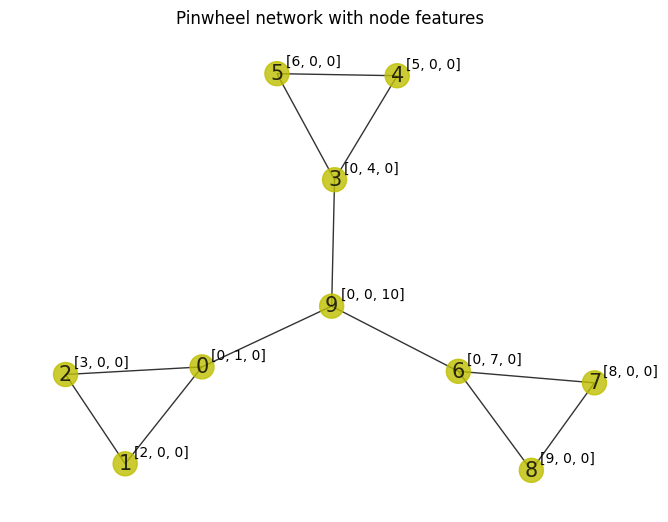

In [9]:
colormap = ["y" for _ in pinwheel_graph.nodes()]
pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato")
plt.figure()
plt.clf()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(pinwheel_graph.nodes[node]['feature']))
_ = plt.title("Pinwheel network with node features")

##### 3.3.1 Step 1: Choose Neighbors

On very large graphs, naive aggregation over every neighbor can become computationally overwhelming. So practical GCN pipelines are often clever about this step and aggregate over a sampled subset of neighbors rather than all neighbors.

For this small pinwheel example, we will keep things simple: each node aggregates from its full 1-hop neighborhood. A 1-hop neighbor is any node connected by a single edge. In matrix terms, the adjacency matrix defines which nodes are adjacent and therefore exchange messages. We also assume an undirected graph so we can focus on the aggregation idea itself.

As we move through the tutorial, this same idea naturally extends to 2-hop, 3-hop, and deeper neighborhoods as additional layers propagate information farther across the graph.

Next, we print each node's 1-hop neighbors to make Step 1 explicit.


In [10]:
for node in pinwheel_graph.nodes: print(f"node {node}'s neighbors are {list(pinwheel_graph.neighbors(node))}")

node 0's neighbors are [1, 2, 9]
node 1's neighbors are [0, 2]
node 2's neighbors are [0, 1]
node 3's neighbors are [4, 5, 9]
node 4's neighbors are [3, 5]
node 5's neighbors are [3, 4]
node 6's neighbors are [7, 8, 9]
node 7's neighbors are [6, 8]
node 8's neighbors are [6, 7]
node 9's neighbors are [0, 3, 6]


##### 3.3.2 Step 2: Receive messages

Now that we know which nodes send messages, we define what each message contains. We will start by describing the process qualitatively, then introduce the matrices and matrix operators that implement each step, and continue that process in the next sections.

At this stage, each node's message is simply its current feature vector. In this notebook, we store node features as row vectors.

For node $i$, write the feature vector as
$$ {\mathbf x}_i = \left[ \begin{array}{cccc}x_{i,1} & x_{i,2} & \ldots & x_{i,f} \end{array}\right] $$

where $f$ is the number of features per node.

Stack these row vectors to form the feature matrix
$$ X = \left[ \begin{array}{c} {\mathbf x}_1 \\ {\mathbf x}_2 \\ \vdots \\ {\mathbf x}_N \end{array}\right] \in \mathbb{R}^{N \times f} $$

where $N$ is the number of nodes in the graph.

In our pinwheel example, each node has a 3-dimensional feature vector, so $f = 3$. In Step 3, we will aggregate these received feature vectors over each node's chosen neighborhood.  The next cell shows what $X$ is for the pinwheel graph.


In [11]:
import numpy as np
X = np.zeros((len(pinwheel_graph.nodes),len(pinwheel_graph.nodes[1]["feature"])))
for node in pinwheel_graph.nodes:
    X[node,:] = np.array(pinwheel_graph.nodes[node]["feature"])
print(f"The feature matrix X has shape {X.shape}")
print(f"The feature matrix X is:\n{X}")

The feature matrix X has shape (10, 3)
The feature matrix X is:
[[ 0.  1.  0.]
 [ 2.  0.  0.]
 [ 3.  0.  0.]
 [ 0.  4.  0.]
 [ 5.  0.  0.]
 [ 6.  0.  0.]
 [ 0.  7.  0.]
 [ 8.  0.  0.]
 [ 9.  0.  0.]
 [ 0.  0. 10.]]


##### 3.3.3 Step 3: Aggregate Messages

Now we choose how to combine incoming neighbor messages. The key requirement is that this aggregation should be permutation-invariant, meaning reordering neighbors does not change the result.

Common aggregation choices include:
- **Sum**: adds all neighbor vectors; preserves total signal magnitude.
- **Average (mean)**: normalizes by neighborhood size; stable across different node degrees.
- **Max**: takes the elementwise maximum across neighbors; keeps the strongest signal in each feature dimension.
- **Attention (weighted sum)**: learns neighbor weights and computes a weighted combination, often with weights that sum to 1.

Using node $i$ and neighborhood $N_i$:
$$
\text{sum: } \hat{\mathbf h}_i = \sum_{j\in N_i}{\mathbf x}_j
$$
$$
\text{average: } \hat{\mathbf h}_i = \frac{1}{|N_i|}\sum_{j\in N_i}{\mathbf x}_j
$$
$$
\text{max: } \hat{\mathbf h}_i[m] = \max_{j\in N_i} {\mathbf x}_j[m]
$$
$$
\text{attention: } \hat{\mathbf h}_i = \sum_{j\in N_i}\alpha_{ij}{\mathbf x}_j, \quad \sum_{j\in N_i}\alpha_{ij}=1
$$

For this tutorial, we use **average** aggregation because it is simple and easy to interpret on the pinwheel graph.

Averaging across neighbors is
$$ \hat{\mathbf h}_i = \frac{1}{k_i} \sum_{j\in N_i} {\mathbf x} _j $$

The hat on $\hat{\mathbf h}_i$ is useful: it indicates the value **after aggregation but before later transformation steps** (such as weighting and activation). If we dropped the hat, we would lose that stage distinction.

Since we know a lot about networks by now, it is easy to rewrite average aggregation as
$$ \hat{\mathbf h}_i = \frac{1}{k_i} \sum_{j=1}^{N} A_{ij} {\mathbf x}_j $$

Pay special attention to the factor $\frac{1}{k_i}$: this is the inverse degree of node $i$, and it is there to convert a raw sum into an average so high-degree nodes do not receive disproportionately large aggregated values just because they have more neighbors.

In matrix form, this becomes
$$ \hat{H} = D^{-1} A X. $$

This expression is analogous to familiar network equations: instead of saying centrality is aggregated from neighbors, we are saying each node's revised feature vector is aggregated from neighbor feature vectors and degree-normalized.


In [12]:
A = nx.linalg.adjacency_matrix(pinwheel_graph).toarray()
D = np.diag([pinwheel_graph.degree[node] for node in pinwheel_graph.nodes])
H = np.linalg.inv(D)@A@X

Let's see if these values make sense. Node 0's neighbors are nodes 1, 2, and 9 with the following characteristics:
 - node 1's feature vector is [2,0,0]
 - node 2's feature vector is [3,0,0]
 - node 9's feature vector is [0,0,10].
  
So, the aggregated value of row 0 should be [2+3, 0, 10] divided by node 0's degree, which is 3, yielding [5/3, 0, 10/3].

[1.67 0.   3.33]


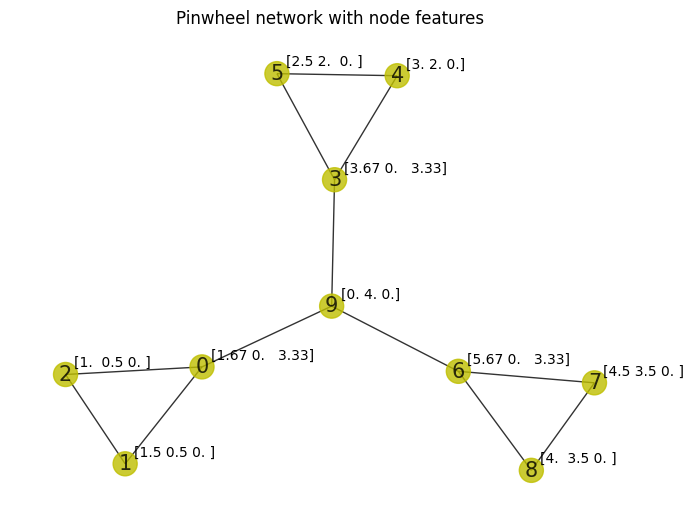

In [13]:
print(np.round(H[0,:],2))
plt.figure()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+5, pos[node][1]+5, str(np.round(H[node,:],2)))
_ = plt.title("Pinwheel network with node features")

##### 3.3.4 Fixing a Problem with Step 3

Pure neighbor averaging can overwrite a node's own **signal**. The word _signal_ just means "whatever the node is currently carrying." At this first layer that is simply the raw feature vector $\mathbf{x}_i$, so signal and feature mean the same thing here. We use the more general word because in later layers a node carries a learned, transformed representation that is no longer the original input features; having a single term that covers both raw features and learned representations avoids confusion as we add more layers.

Without self-loops, the update for node $i$ excludes $\mathbf{x}_i$, so the node's original features are not directly preserved in $\hat{\mathbf h}_i$.

Specifically, look at node 9 after aggregation without self-loops: it gets values from its neighbors, but it does not retain direct information from its own original feature vector.


In [14]:
## Print node 9's feature vector and the signal after aggregation
print(f"Node 9's original feature vector: {pinwheel_graph.nodes[9]['feature']}")
print(f"Node 9's aggregated signal: {np.round(H[9,:],2)}")
print("Node 9 has forgotten the information in the third column of the feature vector, \nwhich was only present in node 9 itself and not in any of its neighbors.")

Node 9's original feature vector: [0, 0, 10]
Node 9's aggregated signal: [0. 4. 0.]
Node 9 has forgotten the information in the third column of the feature vector, 
which was only present in node 9 itself and not in any of its neighbors.


We can fix the problem of a node forgetting its own signal by adding self-loops so each node also "sends a message" to itself. In matrix terms, this means defining
$$ \tilde{A} = A + I $$

For this undirected graph, adding a self-loop contributes **two to a node's degree**, so
$$ \tilde{D} = D + 2I $$

and then using
$$ \hat{H} = \tilde{D}^{-1}\tilde{A}X $$

Mathematically, we write updates using $\tilde{A}$ and $\tilde{D}$. In implementation, we simply add self-loops to the graph and then compute the usual adjacency and degree matrices from that modified graph.

Next, we visualize the graph with self-loops and then compare the resulting aggregated features.


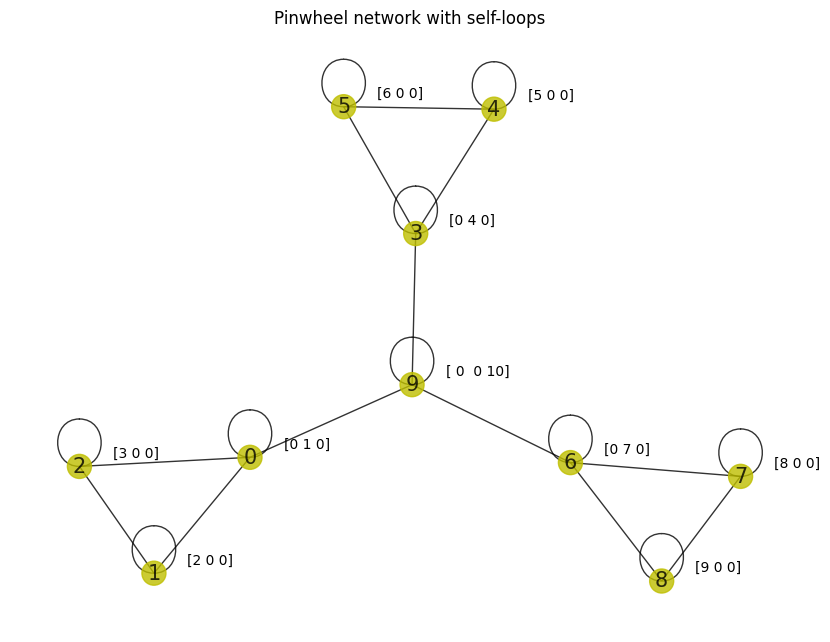

In [15]:
plt.figure(figsize=(8, 6))
# Add self-loops to the graph for visualization
pinwheel_graph.add_edges_from([(i, i) for i in pinwheel_graph.nodes()])
# Recalculate layout with self-loops
pos = nx.nx_pydot.graphviz_layout(pinwheel_graph, prog="neato")
nx.draw(pinwheel_graph, pos, with_labels=True, node_color=colormap, node_size=300, font_size=15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+15, pos[node][1]+5, str(X[node,:].astype(int)))
_ = plt.title("Pinwheel network with self-loops")

Adding self-loops changes the aggregated feature matrix. In the next cell, we compute $\tilde{A}$ and $\tilde{D}$ from the updated graph and inspect $\tilde{D}$ to confirm that every diagonal entry has increased by 2. We then compute $\hat{H} = \tilde{D}^{-1}\tilde{A}X$ and print node 9's row to verify that its own features are now included in the aggregation.

In [16]:
# Graph has self loops added, so just get the adjacency matrix as normal
A_tilde = nx.linalg.adjacency_matrix(pinwheel_graph).toarray()
# Graph has self loops added, so just get the degree matrix as normal
D_tilde = np.diag([pinwheel_graph.degree[node] for node in pinwheel_graph.nodes])
#print(D_tilde)
H_hat = np.linalg.inv(D_tilde)@A_tilde@X
print(f"Node 9's aggregated signal: {np.round(H_hat[9,:],2)} (with self-loops)")
print("Node 9 has retained the information in the third column of the feature vector, \nwhich was only present in node 9 itself, because of the self-loop.")

Node 9's aggregated signal: [0.  2.4 2. ] (with self-loops)
Node 9 has retained the information in the third column of the feature vector, 
which was only present in node 9 itself, because of the self-loop.


Inspect the signal at each node after aggregation to see that each node "remembers" some information about its own features.

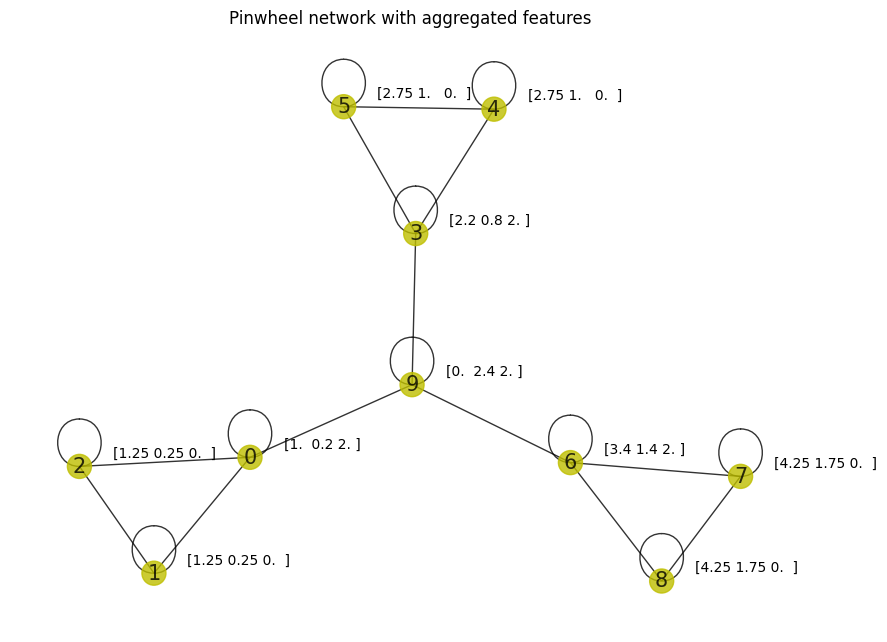

In [17]:
plt.figure(figsize=(8, 6))
nx.draw(pinwheel_graph, pos, with_labels=True, node_color=colormap, node_size=300, font_size=15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+15, pos[node][1]+5, str(np.round(H_hat[node,:],2)))
_ = plt.title("Pinwheel network with aggregated features")

##### 3.3.5 Fixing Another Problem with Step 3: One-Sided Normalization

The previous fix still has a subtle issue: **one-sided normalization**. "One-sided" means we only divide by the **receiving** node's degree $\tilde{d}_i$, completely ignoring how many neighbors the sending node has. A high-degree sender spreads exactly the same signal to each of its recipients regardless of its own connectivity, which can over-inflate the influence of high-degree senders.

If we use

$$ \hat{H} = \tilde{D}^{-1}\tilde{A}X $$

then for node $i$ we can write the row update as

$$ \hat{\mathbf h}_i = \sum_j \left(\tilde{D}^{-1}\tilde{A}\right)_{ij}\mathbf x_j. $$

Now use indexing to expand the matrix product:

$$ \left(\tilde{D}^{-1}\tilde{A}\right)_{ij} = \frac{1}{\tilde d_i}\tilde A_{ij}, $$

so

$$ \hat{\mathbf h}_i = \sum_j \frac{1}{\tilde d_i}\tilde A_{ij}\mathbf x_j = \frac{1}{\tilde d_i}\sum_j \tilde A_{ij}\mathbf x_j. $$

This normalization depends only on $i$ (the receiving node), not on $j$ (the sender).

Ideally, we would account for the degree of **both** the sending node and the receiving node — so that a high-degree sender is down-weighted just like a high-degree receiver. When a normalization treats both sides of the exchange equally in this way, it is called **symmetric**. A standard way to achieve this on both sides is called a **symmetric normalization**, and it gives the formula:

$$ \hat{H} = \tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}X. $$

Since $\tilde{D}$ is a diagonal matrix of node degrees, $\tilde{D}^{-1/2}$ is simply the diagonal matrix whose $i$-th entry is $1/\sqrt{\tilde{d}_i}$. The matrix $\tilde{D}^{-1/2}$ is the diagonal matrix containing the reciprocal square root of each node's degree.

Use the same indexing idea for node $i$:

$$ \hat{\mathbf h}_i = \sum_j \left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\right)_{ij}\mathbf x_j. $$

Because $\tilde D^{-1/2}$ is diagonal,

$$ \left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\right)_{ij}
= \left(\tilde{D}^{-1/2}\right)_{ii}\tilde A_{ij}\left(\tilde{D}^{-1/2}\right)_{jj}
= \frac{1}{\sqrt{\tilde d_i}}\,\tilde A_{ij}\,\frac{1}{\sqrt{\tilde d_j}}.
$$

So

$$ \hat{\mathbf h}_i = \sum_j \frac{\tilde A_{ij}}{\sqrt{\tilde d_i\tilde d_j}}\mathbf x_j. $$

This shows exactly why both sides are normalized:
- $1/\sqrt{\tilde d_i}$ corrects for high-degree receivers

- $1/\sqrt{\tilde d_j}$ corrects for high-degree senders

This symmetric propagation rule is the formula from Kipf \& Welling (2017), the seminal GCN paper. In the next cell, we compute $\hat{H}_{\text{sym}} = \tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}X$ and then plot the resulting node features to compare with the "one-sided version" that uses the equation $\hat{H} = \tilde{D}^{-1}\tilde{A}X$.

The next cell shows the signal for node 3 under the one-sided and symmetric computations. Node 3 is chosen because it receives a signal from the relatively high degree node 9.


In [18]:
# A_tilde and D_tilde already include self-loops from the graph
H_sym = np.linalg.inv(np.power(D_tilde,0.5)) @ A_tilde @ np.linalg.inv(np.power(D_tilde,0.5)) @ X

print(f"Node 3 one-sided ($\\hat{{H}}$):          {np.round(H_hat[3,:],2)}")
print(f"Node 3 symmetric ($\\hat{{H}}_{{sym}}$): {np.round(H_sym[3,:],2)}")
print()
print("Node 3 receives signal from node 9 through edge (3,9).")
print("Under symmetric normalization, node 9 is down-weighted as a sender by 1/sqrt(d_9),")
print("so node 9's contribution to node 3 is smaller relative to other parts of the vector\nthan in the one-sided version.")


Node 3 one-sided ($\hat{H}$):          [2.2 0.8 2. ]
Node 3 symmetric ($\hat{H}_{sym}$): [2.46 0.8  2.  ]

Node 3 receives signal from node 9 through edge (3,9).
Under symmetric normalization, node 9 is down-weighted as a sender by 1/sqrt(d_9),
so node 9's contribution to node 3 is smaller relative to other parts of the vector
than in the one-sided version.


Let's inspect what the features of the nodes are after these aggregation operations.

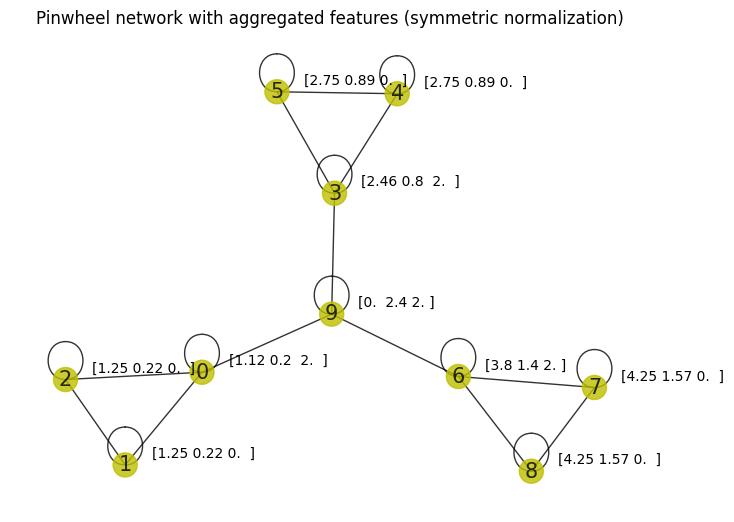

In [19]:
plt.figure()
# Self-loops are already present in pinwheel_graph
pos = nx.nx_pydot.graphviz_layout(pinwheel_graph, prog="neato")
nx.draw(pinwheel_graph, pos, with_labels = True, node_color = colormap, node_size = 300, font_size = 15, alpha = 0.8)
for node in pos.keys():
    plt.text(pos[node][0]+15, pos[node][1]+5, str(np.round(H_sym[node,:],2)))
_ = plt.title("Pinwheel network with aggregated features (symmetric normalization)")
plt.show()

##### 3.3.6 An Aside: Similar Matrix Patterns, Different Objects
You've now seen two matrix patterns that look similar but play different roles:
- **GCN symmetric aggregation operator**: $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$
- **Symmetric normalized Laplacian**: $\tilde{D}^{-1/2}\tilde{L}\tilde{D}^{-1/2}$, where $\tilde{L}=\tilde{D}-\tilde{A}$

You can also compare the one-sided version from message passing to a one-sided Laplacian-style form:
- **One-sided aggregation**: $\tilde{D}^{-1}\tilde{A}$
- **One-sided Laplacian-style form**: $\tilde{D}^{-1}\tilde{L}=I-\tilde{D}^{-1}\tilde{A}$

The structural similarity is that both families use degree matrices to normalize how connectivity contributes.
The difference is what matrix is being normalized:
- with $\tilde{A}$, we get a **propagation/aggregation** operator (mix neighbor features);
- with $\tilde{L}$, we get a **difference/smoothness** operator (compare a node to its neighborhood).

So it is useful to recognize the shared algebraic pattern while remembering these operators are not the same object and do not serve the same purpose.

##### 3.3.7 Aside: Why call it "convolutional"?

You may notice the term "Graph **Convolutional** Neural Network." This word "convolutional" comes from image processing, where a **convolution** is an operation that combines a value at each pixel with values from its neighboring pixels to produce a filtered output.

The key idea that carries over to GCNs is **local neighborhood processing**: in both image CNNs and GCNs, each unit (pixel or node) looks at its immediate neighbors, aggregates their information, and transforms the result. That is what we have been doing throughout this section—each node aggregates neighbor signals via the adjacency matrix, then we transform that aggregated signal with weights and activation.

The differences are important:
- Image pixels live on a fixed 2D grid with uniform neighborhoods (e.g., a 3×3 window); graph nodes live on an irregular structure defined by edges.
- Image CNNs use the mathematical convolution operator; GCNs use the adjacency matrix for neighborhood aggregation.

So the term "convolutional" in GCNs is a **conceptual analogy** rather than a mathematical one. It highlights that both methods perform local neighborhood aggregation, but GCNs adapt this idea to work on arbitrary graphs.

---

#### 4. Transforming the Aggregated Signal

At this point in a GCN layer, each node has aggregated the feature vectors from its neighbors via the propagation step. The result is a neighborhood-aware signal for each node. But we do not pass this signal directly to the next layer. Instead, we first **transform** it using learned weights and nonlinear **activations**. This section explains how we take the aggregated signal and prepare it for the next layer of the network.

#### 4.1 Two Core Steps

Every GCN layer has two key components:

**Propagation Step (Neighborhood Aggregation)**

This is the part we've been doing so far: each node collects and combines the feature vectors from its neighbors using the graph structure and degree normalization. Mathematically, this is the part that produces

$$\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}X$$

where the matrix product gathers neighbor information. This is sometimes called the *aggregation* step because each node aggregates neighbor signals.

**Transformation Step (Weighting and Activation)**

After neighborhood aggregation, we transform the aggregated signal using two sub-steps:

- **Weighting**: Multiply by a learnable weight matrix $W$ to extract useful feature combinations.

- **Activation**: Apply a nonlinear function (like ReLU or sigmoid) to introduce nonlinearity and allow the network to model complex patterns.

Together, weighting and activation form what we call the *transformation* step. The output signal from this step becomes the input to the next GCN layer, and the cycle repeats.

The sections below explain transformation in detail.

#### 4.2 Transformation Step 1 -- Weighting

So far, each node has produced an aggregated message from its neighborhood (for example, $\hat{\mathbf h}_i$). We will call this quantity the node's **signal**. At this stage, signal means the aggregated feature message that came out of the propagation step.

A neural network layer then transforms this signal. In this tutorial, we separate that transformation into two parts:
- weighting (a learned linear map), then
- activation (a nonlinear function).

For weighting, each layer multiplies the incoming signal by a learnable matrix $W$. Intuitively, learning $W$ means learning which combinations of input features are useful for the task.

Using one-sided notation at the node level:
$$
{\mathbf h}_i = \left(\frac{1}{k_i}\sum_{j=1}^{n} A_{ij}{\mathbf x}_j\right)W.
$$

Using symmetric normalization in matrix form:
$$
H = \tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}XW.
$$

The key idea is that propagation builds a neighborhood-aware signal, and weighting learns how to transform that signal into more useful hidden features.

##### 4.2.1 Choosing the Dimension of $W$

Now we need to choose the weight matrix $W$. The dimensions of $W$ define how many input features we are combining and how many output features we create.

Specifically, if the aggregated signal has $f_{\text{in}}$ features and we want the weighted output to have $f_{\text{out}}$ features, then $W$ is a matrix of shape $f_{\text{in}} \times f_{\text{out}}$.

**Practical meaning of dimensions:**
- $f_{\text{in}}$ is the feature dimension of the aggregated signal (the input to this layer).
- $f_{\text{out}}$ is the number of features we want to create for the next layer (the output of this layer).
- Each element $W_{ij}$ represents how much the $i$-th input feature contributes to the $j$-th output feature.

**Design choice: How large should $f_{\text{out}}$ be?**
- **Expansion** ($f_{\text{out}} > f_{\text{in}}$): Creates more output features than input features. This is common in the hidden layers of deep networks because it allows the network to learn richer, more varied representations.
- **Bottleneck** ($f_{\text{out}} < f_{\text{in}}$): Reduces the number of features. This is useful for compression or focusing on the most important patterns. It also reduces the number of parameters that need to be learned.
- **Same size** ($f_{\text{out}} = f_{\text{in}}$): Maintains the same number of features while transforming them.

In this example, the pinwheel has 3 input features, but we will choose 2 output features for visualization simplicity. In practice, you would often expand the feature dimension in hidden layers and then compress it in the final output layer.

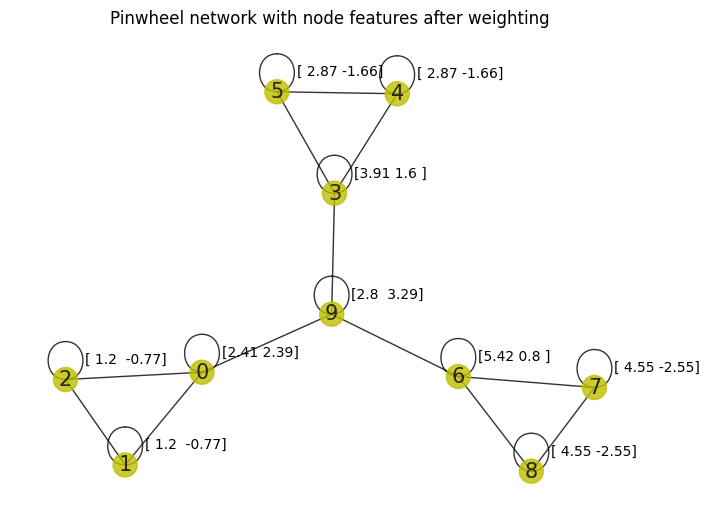

In [20]:
num_features_level0 = len(pinwheel_graph.nodes[1]["feature"])
num_features_level1 = 2
W = np.random.normal(size=(num_features_level0,num_features_level1))
H = np.linalg.inv(np.power(D_tilde,0.5)) @ A_tilde @ np.linalg.inv(np.power(D_tilde,0.5)) @ X @ W
plt.figure()
nx.draw(pinwheel_graph,pos,with_labels = True,node_color = colormap, node_size = 300,font_size = 15, alpha=0.8)
for node in pos.keys():
    plt.text(pos[node][0]+11, pos[node][1]+11, str(np.round(H[node,:],2)))
_ = plt.title("Pinwheel network with node features after weighting")

#### 4.2.2 Aside: Checking the dimensions of the matrices

**Why check dimensions?** When working with matrix products, checking dimensions is a simple way to catch mistakes early and verify that the data flows through the network as expected.

Let's trace the dimensions through one GCN layer:
- Let $n$ = number of nodes and $f_{\text{in}}$ = number of input features.
- Let $f_{\text{out}}$ = number of output features (which we chose earlier).

**Input to the layer:**
- Aggregated signal $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}X$ has shape $n \times f_{\text{in}}$ (each row is one node's aggregated signal).

**Weighting:**
- Weight matrix $W$ has shape $f_{\text{in}} \times f_{\text{out}}$ (we chose $f_{\text{out}}$).
- Product $(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}X)W$ has shape $n \times f_{\text{out}}$.

**Key insight:** Because $W$ is shared across all nodes (every node multiplies its aggregated signal by the same $W$), the network applies the same learned transformation to every node's neighborhood-aware signal. This parameter sharing is a form of regularization and makes the network's learned features graph-aware.

In subsequent layers, $f_{\text{in}}$ becomes the output dimension from the previous layer, and the process repeats.

#### 4.3 Segue: Adding layers to the Network

Look again at the figure from Kipf's tutorial, which I'll replicate here for convenience.

<img src="figures/Kipf_figure.png" alt="Kipf GCN architecture" width = "600">

Why do we need multiple layers? Consider what each layer accomplishes in terms of receptive field:

- **Layer 1 (first hidden layer)**: Each node aggregates information from its 1-hop neighbors. The propagation step gathers feature signals from immediate neighbors, and the transformation step (weighting + activation) processes that aggregated signal.

- **Layer 2 (second hidden layer)**: Each node now aggregates the *transformed* aggregated signals from layer 1. This pulls in information from 2-hop neighbors, using aggregating signals from neighbors of neighbors. These 2-hop connections reveal higher-order graph structures and long-range dependencies that single-hop aggregation misses.

- **Layer 3 (third hidden layer)**: Following the same pattern, layer 3 nodes aggregate information from 3-hop neighbors, capturing even deeper structural patterns.


##### 4.3.1 The Trade-Off: Depth vs. Over-Smoothing

This connects directly to the framing from the introduction:

- Centrality methods aggregate information globally across the whole graph.
- DeepWalk and Node2Vec aggregate information within a finite walk window.
- GCNs aggregate information locally, where locality is controlled by depth: a model with L layers aggregates up to roughly L-hop neighborhoods.

As we add layers, each node can incorporate richer structural context from farther away in the graph. But if we stack too many graph-aggregation layers, node representations can become too similar, and we lose node-specific information needed for prediction. This is the over-smoothing trade-off. In practice, the papers I've read suggest that 2-3 hidden GCN layers often provide a good balance between structural context and node distinguishability. 

(In a later class, we will introduce a linear bypass layer (a skip-style path) to help preserve node identity while still benefiting from deeper graph aggregation.)


#### 4.3.2 Notation for aggregating layers

Following the example from both the Stanford class and from [Kipf's github description](https://tkipf.github.io/graph-convolutional-networks/), we'll use a superscript enclosed in parentheses to indicate which layer we are at. If we let the original feature vector be layer 0, then we can write $H^{0}=X$ and rewrite the equation above as

$$ H^{(1)} =  \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(0)} W^{(0)}$$

And we can write the value for each hidden layer in terms of the value of the previous hidden layer as

$$ H^{(\ell+1)} = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} \phi\left(H^{(\ell)}\right) W^{(\ell)} $$

where $\phi$ denotes the activation function (for example, ReLU, sigmoid, or tanh).

We'll talk a little bit about specific activation functions a little later in this tutorial, but not enough for you to have a good understanding. Sorry


#### 4.4 Transformation Step 2: Activation

After propagation and weighting, we apply an **activation function**. In neural networks, activation introduces nonlinearity into each layer.

Why this matters:
- Without activation, stacking multiple layers is still equivalent to a single linear transformation.
- With activation, each layer can model nonlinear structure, which increases expressive power.

Using layer notation, a standard GCN update is

$$
H^{(\ell+1)} = \phi\!\left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}H^{(\ell)}W^{(\ell)}\right).
$$

So each layer follows the same pattern:
- propagate neighborhood information,
- apply a learned linear transform,
- apply a nonlinear activation.

Stacking layers still expands receptive field (roughly 1-hop, 2-hop, 3-hop, ...), but activation is what prevents the model from collapsing into a purely linear mapping.

Next, we summarize common activation choices (4.4.1) and then walk through a concrete sigmoid example on the pinwheel graph (4.4.2).

##### 4.4.1 Choosing hidden-layer activations: what these terms mean

Before choosing an activation, it helps to define what the layer is carrying.

A **hidden signal** means an intermediate feature vector inside the network (for example, rows of $H^{(\ell)}$ in hidden layers). It is called a signal because it carries transformed neighborhood information from one layer to the next.

Common hidden-layer choices:
- **ReLU**: a strong default in many GCNs because it is simple, fast, and usually easy to optimize.
- **tanh**: maps values to $[-1,1]$, which gives bounded, zero-centered hidden signals.
- **sigmoid**: maps values to $[0,1]$ and is often used when a layer is acting as a gate.

| Activation Function | Equation | Output Range |
|---|---|---|
| ReLU | $\mathrm{ReLU}(x)=\max(0,x)$ | $[0,\infty)$ |
| tanh | $\tanh(x)=\dfrac{e^x-e^{-x}}{e^x+e^{-x}}$ | $[-1,1]$ |
| Sigmoid | $\sigma(x)=\dfrac{1}{1+e^{-x}}$ | $[0,1]$ |

What is **saturation**?

For sigmoid and tanh, large-magnitude inputs push outputs close to their limits:
- sigmoid near 0 or 1,
- tanh near -1 or 1.

In these regions, the slope is very small, so changing the input barely changes the output. During training, this can produce tiny gradients and slow learning.

What are **gating-style components**?

A gate is a learned control value that decides how much information to pass. A common pattern is:
- compute a gate value (often with sigmoid),
- multiply that gate by another hidden signal,
- interpret values near 0 as "block," near 1 as "pass," and intermediate values as "partially pass."

Why might zero-centered hidden signals in $[-1,1]$ be useful?

With tanh-like hidden states, representations can carry both positive and negative evidence around zero instead of only positive values. This can make optimization behavior more balanced and can help stabilize internal feature magnitudes across layers. The trade-off is that tanh can still saturate when inputs are very large in magnitude.

##### 4.4.2 Example: compare ReLU, tanh, and sigmoid on the same weighted output

In this example, we start from the same weighted hidden signal and then apply each activation separately so we can compare how they transform the values.

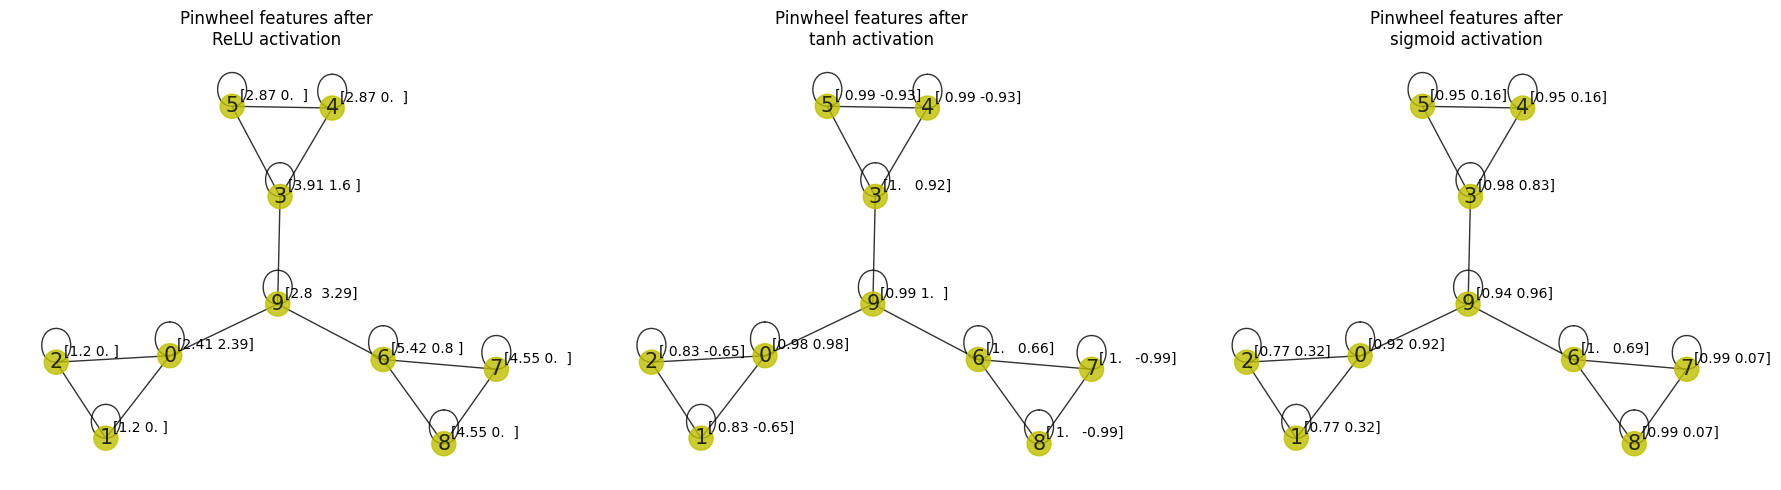

In [21]:
from scipy.special import expit  # Sigmoid

# Keep a copy of the weighted output before activation
H_weighted = H.copy()

# Apply three common hidden-layer activations to the same weighted signal
H_relu = np.maximum(0, H_weighted)
H_tanh = np.tanh(H_weighted)
H_sigmoid = expit(H_weighted)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
activations = [
    ("ReLU activation", H_relu),
    ("tanh activation", H_tanh),
    ("sigmoid activation", H_sigmoid),
]

for ax, (title, H_act) in zip(axes, activations):
    plt.sca(ax)
    nx.draw(pinwheel_graph, pos, with_labels=True, node_color=colormap, node_size=300, font_size=15, alpha=0.8)
    for node in pos.keys():
        plt.text(pos[node][0] + 5, pos[node][1] + 5, str(np.round(H_act[node, :], 2)))
    _ = plt.title(f"Pinwheel features after\n{title}")

plt.tight_layout()

What to look for in each activation plot:

- **ReLU**: negative values are clipped to 0, so outputs are never negative. Watch for exact zeros where information is suppressed.
- **tanh**: values are scaled into $[-1,1]$ and remain zero-centered, so both positive and negative evidence are preserved.
- **sigmoid**: values are mapped into $(0,1)$, so all outputs are positive and bounded.

To make this concrete, the next cell automatically finds a node where these transformations differ the most and prints a side-by-side comparison.

In [22]:
# Find a node where activations disagree the most
# Score = spread among activation outputs + amount of sign-mixed pre-activation signal
activation_stack = np.stack([H_relu, H_tanh, H_sigmoid], axis=0)  # (3, num_nodes, num_features)
spread_score = np.mean(np.std(activation_stack, axis=0), axis=1)   # per node

has_pos = (H_weighted > 0).any(axis=1)
has_neg = (H_weighted < 0).any(axis=1)
sign_mix_bonus = (has_pos & has_neg).astype(float)

interesting_score = spread_score + sign_mix_bonus
node_to_inspect = int(np.argmax(interesting_score))

print(f"Most illustrative node: {node_to_inspect}")
print(f"Weighted signal before activation: {np.round(H_weighted[node_to_inspect, :], 3)}")
print(f"After ReLU:   {np.round(H_relu[node_to_inspect, :], 3)}")
print(f"After tanh:   {np.round(H_tanh[node_to_inspect, :], 3)}")
print(f"After sigmoid:{np.round(H_sigmoid[node_to_inspect, :], 3)}")
print()

# Brief interpretation helper
num_zero_relu = int(np.sum(np.isclose(H_relu[node_to_inspect, :], 0.0)))
print(f"ReLU set {num_zero_relu} feature(s) exactly to zero.")
print("tanh keeps sign and compresses magnitudes into [-1, 1].")
print("sigmoid maps all features to positive values in (0, 1).")

Most illustrative node: 7
Weighted signal before activation: [ 4.552 -2.555]
After ReLU:   [4.552 0.   ]
After tanh:   [ 1.    -0.988]
After sigmoid:[0.99  0.072]

ReLU set 1 feature(s) exactly to zero.
tanh keeps sign and compresses magnitudes into [-1, 1].
sigmoid maps all features to positive values in (0, 1).


---

##### 5. Designing Hidden Layers and the Output Layer

Designing a GCN is partly mathematical and partly a subjective modeling choice. There is rarely one universally correct architecture.

In practice, you usually choose:
- how many hidden layers to stack,
- the dimension of each hidden layer,
- and the output function for your task.

The next subsections walk through these decisions with the pinwheel example.

#### 5.1 Depth and Width: Choosing the Numbers and Dimensions of Hidden Layers

Choosing hidden-layer architecture is a subjective design decision guided by trade-offs rather than a fixed rule.

In this section:
- **5.1.1 (Depth)** explains how the number of hidden layers affects receptive field, over-smoothing risk, and optimization difficulty.
- **5.1.2 (Width)** explains how hidden-layer dimensions control representational capacity, compression, and parameter count.
- **5.1.3 (Example)** compares several depth/width configurations on the pinwheel graph so you can see how layer outputs change in practice.

Together, these subsections provide a practical framework for choosing depth and width before moving on to output-layer design.

##### 5.1.1 Depth: Choosing the Number of Hidden Layers

Before choosing depth, remember why we are studying GCNs in this course: they let us combine
- **graph-structure information** (the same kind of network signal we use in centrality, random walks, DeepWalk/Node2Vec), and
- **node feature information** (attributes attached to each node).

Depth controls how far structure-aware information can propagate through the network while still preserving useful node-feature signal.

- **Depth**: More layers increase receptive field (1-hop, 2-hop, 3-hop, ...), which can capture broader structure.
- Too many layers can over-smooth node representations, making nodes look too similar.
- Deeper models also increase optimization difficulty and computational cost.

A common starting point is 1-3 hidden layers, then adjust based on validation performance and interpretability needs.

##### 5.1.2 Width: Choosing Hidden-Layer Dimensions

After depth, choose the **width** (feature dimension) at each hidden layer.

A useful network-analysis perspective is to separate the **final hidden layer** from the **earlier hidden layers**.

- **Final hidden-layer width** often has the clearest interpretation: it is the dimension of the embedding you keep, similar to choosing how many Laplacian eigenvectors to retain in spectral embedding.
- **Earlier hidden-layer widths** are usually less directly interpretable in a spectral sense. They act more like intermediate representational capacity: how many structural-feature patterns the model can build before compressing into the final embedding.

So a practical strategy is:
- choose the final hidden width using embedding-oriented reasoning (expected complexity, clustering goals, interpretability),
- choose earlier widths using capacity/optimization reasoning (enough channels to combine graph structure and node features without overfitting).

Trade-offs for width choices:
- Wider layers can represent richer patterns but add parameters and risk overfitting.
- Narrower layers force compression, which can improve robustness but may discard useful signal.
- A common pattern is to gradually reduce dimensions across layers (for example, 6 -> 4 -> 2) to produce compact representations.

There is no single best width schedule. It depends on graph size, feature complexity, label sparsity, and whether your goal is prediction accuracy or interpretable embeddings.

The next cell compares several depth/width choices on the pinwheel network and shows each layer's node outputs.

##### 5.1.3 Example: What changes when depth and width change?

This demonstration compares three hidden-layer architectures on the same pinwheel input features:
- `1 layer: [2]`
- `2 layers: [4, 2]`
- `3 layers: [6, 4, 2]`

For each architecture, the code shows two outputs:
1. **Graph plots for each layer**: each node is annotated with that layer's hidden signal (first two coordinates shown for readability).
2. **A numeric trace for one node (node 9)**, for example:
   - `1 layer: [2]` -> `layer 1: [0.58, 1.765]`
   - `2 layers: [4, 2]` -> `layer 1: [0., 4.405, 2.565, 0.]`, `layer 2: [0., 1.702]`
   - `3 layers: [6, 4, 2]` -> `layer 1: [0., 0.023, 0., 4.217, 0., 0.]`, `layer 2: [1.589, 0.101, 0.109, 0.]`, `layer 3: [0., 0.195]`

How to read these vectors:
- The **length of each vector** equals the width of that layer (for example, width 6 gives a 6-dimensional hidden signal).
- Each entry is a learned hidden feature value after propagation, weighting, and ReLU activation at that layer.
- Zeros often appear because ReLU clips negative pre-activation values to 0.

Layer-output traces for node 9:

1 layer: [2]
  layer 1: [0.58  1.765]

2 layers: [4, 2]
  layer 1: [0.    4.405 2.565 0.   ]
  layer 2: [0.    1.702]

3 layers: [6, 4, 2]
  layer 1: [0.    0.023 0.    4.217 0.    0.   ]
  layer 2: [1.589 0.101 0.109 0.   ]
  layer 3: [0.    0.195]


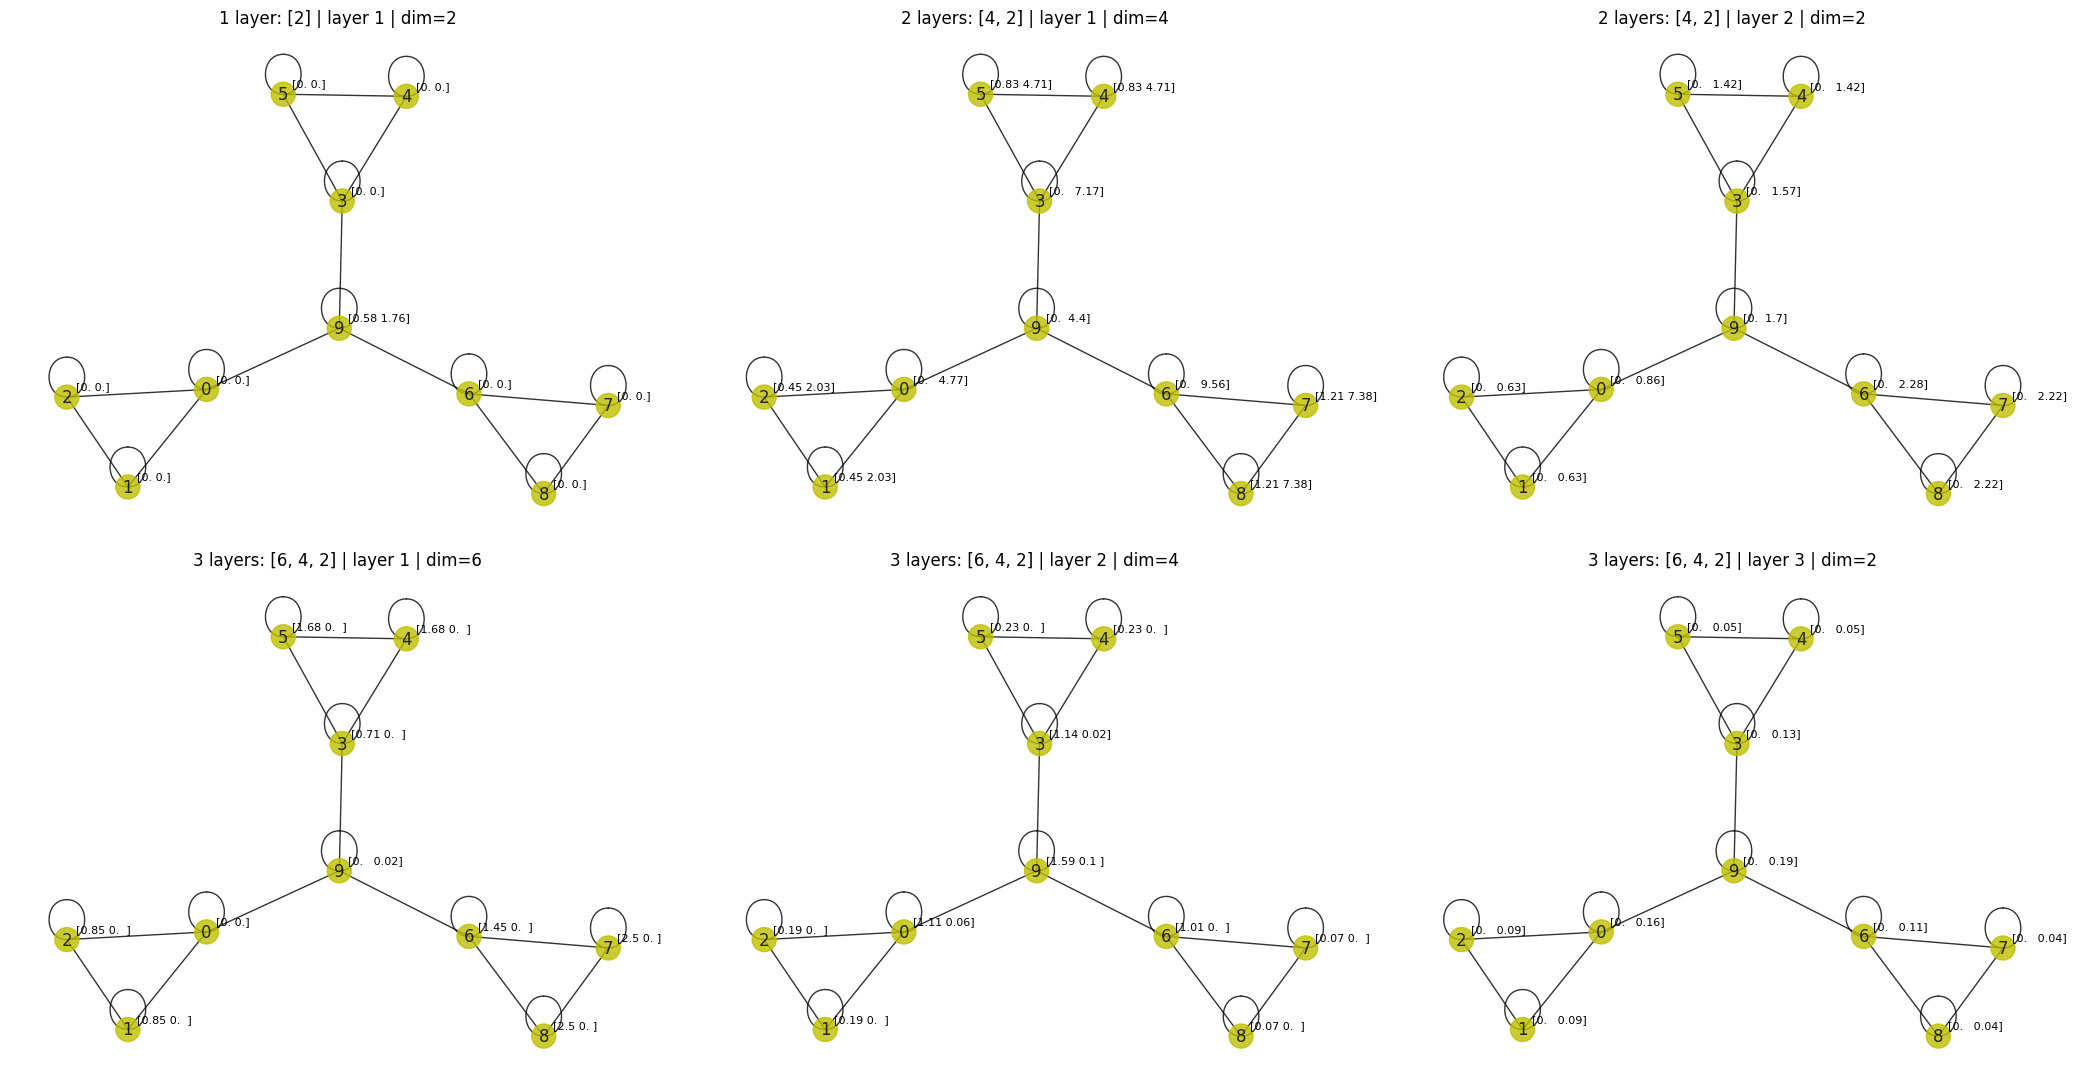

In [23]:
# Compare layer outputs for different depth/width choices on the pinwheel graph
prop = np.linalg.inv(np.power(D_tilde, 0.5)) @ A_tilde @ np.linalg.inv(np.power(D_tilde, 0.5))


def run_hidden_stack(X0: np.ndarray, hidden_dims: list[int], seed: int):
    rng = np.random.default_rng(seed)
    H_current = X0.copy()
    layer_outputs = []
    in_dim = H_current.shape[1]

    for layer_idx, out_dim in enumerate(hidden_dims, start=1):
        W_layer = rng.normal(loc=0.0, scale=0.7, size=(in_dim, out_dim))
        Z_layer = prop @ H_current @ W_layer
        H_current = np.maximum(0, Z_layer)  # ReLU hidden activation
        layer_outputs.append((layer_idx, H_current))
        in_dim = out_dim

    return layer_outputs


def format_vec_2(v: np.ndarray) -> str:
    if len(v) == 1:
        return str(np.round(v[:1], 2))
    return str(np.round(v[:2], 2))


configs = {
    "1 layer: [2]": [2],
    "2 layers: [4, 2]": [4, 2],
    "3 layers: [6, 4, 2]": [6, 4, 2],
}

all_views = []
for cfg_idx, (cfg_name, dims) in enumerate(configs.items(), start=1):
    outputs = run_hidden_stack(X, dims, seed=100 + cfg_idx)
    for layer_idx, H_layer in outputs:
        all_views.append((f"{cfg_name} | layer {layer_idx} | dim={H_layer.shape[1]}", H_layer))

fig, axes = plt.subplots(2, 3, figsize=(21, 11))
axes = axes.flatten()

for ax, (title, H_layer) in zip(axes, all_views):
    plt.sca(ax)
    nx.draw(pinwheel_graph, pos, with_labels=True, node_color=colormap, node_size=300, font_size=12, alpha=0.8)
    for node in pos.keys():
        plt.text(pos[node][0] + 5, pos[node][1] + 5, format_vec_2(H_layer[node, :]), fontsize=8)
    _ = plt.title(title)

for ax in axes[len(all_views):]:
    ax.axis("off")

plt.tight_layout()

# Print one-node traces to make layer-by-layer differences explicit
inspect_node = 9
print(f"Layer-output traces for node {inspect_node}:")
for cfg_idx, (cfg_name, dims) in enumerate(configs.items(), start=1):
    outputs = run_hidden_stack(X, dims, seed=100 + cfg_idx)
    print(f"\n{cfg_name}")
    for layer_idx, H_layer in outputs:
        print(f"  layer {layer_idx}: {np.round(H_layer[inspect_node, :], 3)}")

What this demonstrates:
- Changing **depth** changes how many rounds of message passing and transformation occur.
- Changing **width** changes how much intermediate representational capacity each layer has.
- Even with the same final width (2), different depth/width paths can produce different final node representations.
eff
Note: because weight matrices are initialized randomly, the exact values you see will differ across runs unless a fixed seed is used (which this code does via the `seed` argument to `run_hidden_stack`).

---

#### 5.2 Choosing an Output Function

After designing hidden layers, the final design choice is the output function (and matching loss) used at the last layer.

This choice determines:
- how raw model scores are interpreted,
- what error signal is computed during training,
- and how gradients flow back to update earlier weights.

So output design is not just presentation; it is part of the optimization dynamics of the entire network.

##### 5.2.1 Common Output Functions

Common output choices depend on what you want the model to predict:

- **Softmax**: for single-label classification (exactly one class per node).
- **Sigmoid**: for multi-label classification (each class is an independent yes/no decision).
- **Linear (no squashing)**: for regression targets or when you want unconstrained embeddings.

| Output Function | What You Want to Predict |
|---|---|
| Softmax | A single class label per node (multi-class classification) |
| Sigmoid | Multiple independent yes/no labels per node (multi-label classification) |
| Linear (no activation) | A continuous value (regression) or an unconstrained embedding vector |

Each output function induces a different geometry of scores and therefore a different notion of prediction error.

**Reconnecting with network analysis: reconstruction loss**

One output that connects directly to the network analysis ideas in this course is a **reconstruction loss**. The idea is to train the GCN so that the inner product of two node embeddings predicts whether those nodes are connected. The last GCN layer is **linear** (no activation), producing unconstrained embedding vectors $Z$. The sigmoid is applied *outside* the network, only when computing the predicted edge probability:

$$\hat{A}_{ij} = \sigma(z_i^\top z_j).$$

The output layer itself does not squash; it simply maps the final hidden signal to the embedding space. The loss then compares these predicted edge probabilities to the actual adjacency matrix.

Why is this familiar? You have already seen the idea that two nodes sharing many neighbors or appearing near each other in random walks should have similar representations. Reconstruction loss operationalizes the same intuition: nodes that are connected end up with similar embedding vectors, and nodes that are not connected end up with dissimilar ones. DeepWalk and Node2Vec use a similar objective (predicting walk co-occurrence), but here the GCN also incorporates node features during embedding — which is what makes GCN-based reconstruction more expressive than purely walk-based methods.

We will revisit reconstruction loss in more detail in a subsequent class. For now, the key point is that it is a natural bridge between the network analysis ideas you already know and the GCN output layer.



##### 5.2.2 Steps for Training GCN

Every GCN training loop repeats four steps:

1. **Forward pass**: run the input features $X$ and graph structure $\tilde{A}$ through all hidden layers and the output layer to produce predictions.
2. **Compute loss**: compare predictions to targets using the loss function that matches the output layer.
3. **Backward pass**: compute gradients of the loss with respect to every weight matrix $W^{(0)}, W^{(1)}, \ldots$ by propagating the error signal backward through the network.
4. **Optimizer step**: update the weights in the direction that reduces the loss.

### 6. "Real-world" Example

I asked ChatGPT 4.o to help me construct a real-world example. The specifications I gave it were that I needed 
- Three authors of childrens stories whose work is in the public domain
- Each author must have at least three stories
- Each story must have something in common with the other stories

I also asked for an article of blog that summarized similarities and differences among the stories. It hallucinated a response, but the response serves the purpose that I need so I'll use it.  I asked for a summary in csv so that I could read it into a pandas dataframe

<img src="figures/Transformer_ready_childrens_stories.png" alt="Summary of children's stories for node labels" width = "800">

This section briefly describes how I created a feature vector and the graph that uses the information above in a GCN Demonstration.

#### 6.1 What Data Do We Have

The code loads a CSV file called `Transformer_Ready_Stories_With_Node0.csv` using pandas. Each row corresponds to one node in the pinwheel network:

- Rows 0–2: three Beatrix Potter stories (nodes 1–3)
- Rows 3–5: three Rudyard Kipling stories (nodes 7–9)
- Rows 6–8: three Aesop's Fables (nodes 4–6)
- Row 9: a "Common Themes" summary paragraph that will serve as the hub node (node 0)

The most important column is `text`, which contains a short narrative description of each story. That prose description is what the transformer in the next step will encode into a numerical feature vector. Calling `df.head()` lets you inspect the column names and the first few rows of story text.

In [24]:
############
## Cell 1 ##
############

import pandas as pd

# Load transformer-ready CSV
df: pd.DataFrame = pd.read_csv("datasets/Transformer_Ready_Stories_With_Node0.csv")
df.head()

,author,title,text
0,Beatrix Potter,The Tale of Peter Rabbit,The Tale of Peter Rabbit: Once upon a time the...
1,Beatrix Potter,The Tale of Benjamin Bunny,The Tale of Benjamin Bunny: One morning a litt...
2,Beatrix Potter,The Tale of Jemima Puddle-Duck,The Tale of Jemima Puddle-Duck: What a funny s...
3,Rudyard Kipling,Mowgli’s Brothers (from The Jungle Book),Mowgli’s Brothers (from The Jungle Book): Now ...
4,Rudyard Kipling,Kaa’s Hunting,Kaa’s Hunting: His spots are the joy of the Le...


#### 6.2 Encoding Story Descriptions as Feature Vectors

The code uses a pre-trained **sentence transformer** (`paraphrase-MiniLM-L6-v2`) to convert each row's `text` description into a dense numerical vector.

A sentence transformer passes each text string through a BERT-style encoder and then pools the resulting token embeddings into a single fixed-length vector. The key property is that semantically similar sentences end up geometrically close to one another in this vector space — so stories with similar themes, characters, or morals will have feature vectors that point in similar directions.

`model.encode(...)` processes all ten rows at once and returns a 2D NumPy array `node_features` of shape **(10, 384)**: one 384-dimensional vector per row. These will become the initial node feature vectors fed into the GCN.

In [25]:
############
## Cell 2 ##
############

## Requires pip install sentence-tranformers
from sentence_transformers import SentenceTransformer
from numpy.typing import NDArray

# Load model
model: SentenceTransformer = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Create node features
node_features: NDArray = model.encode(df["text"].tolist(), show_progress_bar=True)
print(f"The feature vector for node 0 has {node_features.shape[1]} rows")

/Users/mike/Dropbox/Mac/Documents/Classes/CS 575/Winter 2026/Code/winter-2026-cs-575/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11526.50it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1/1 [00:00<00:00,  4.85it/s]

The feature vector for node 0 has 384 rows


#### 6.3 Build the Pinwheel Graph and Assign Story Labels

The code reconstructs the pinwheel topology as a NetworkX graph `G` and attaches a human-readable story title to each node.

**Graph structure:** There are 10 nodes (0–9). Three triangles represent the three authors' story clusters:
- **Nodes 1–3** (Beatrix Potter): *Peter Rabbit*, *Benjamin Bunny*, *Jemima Puddle-Duck*
- **Nodes 4–6** (Aesop's Fables): *Tortoise and Hare*, *Fox and Grapes*, *Lion and Mouse*
- **Nodes 7–9** (Rudyard Kipling): *Mowgli's Brothers*, *Kaa's Hunting*, *Tiger! Tiger!*

**Hub node:** Node 0 ("Common Themes") is connected to one node from each cluster (nodes 1, 4, and 7), creating the "pinwheel" shape — three petal triangles radiating from a central hub.

The `node_map` dictionary stores each node's story title by integer ID. The loop at the end writes that same title into each node's attribute dictionary under the key `"node_label"`, so the label travels with the graph object and can be used later for visualization and inspection. The graph is then drawn so you can confirm the pinwheel structure and verify that the story labels are placed correctly.

Node 1's label is 'Peter Rabbit'


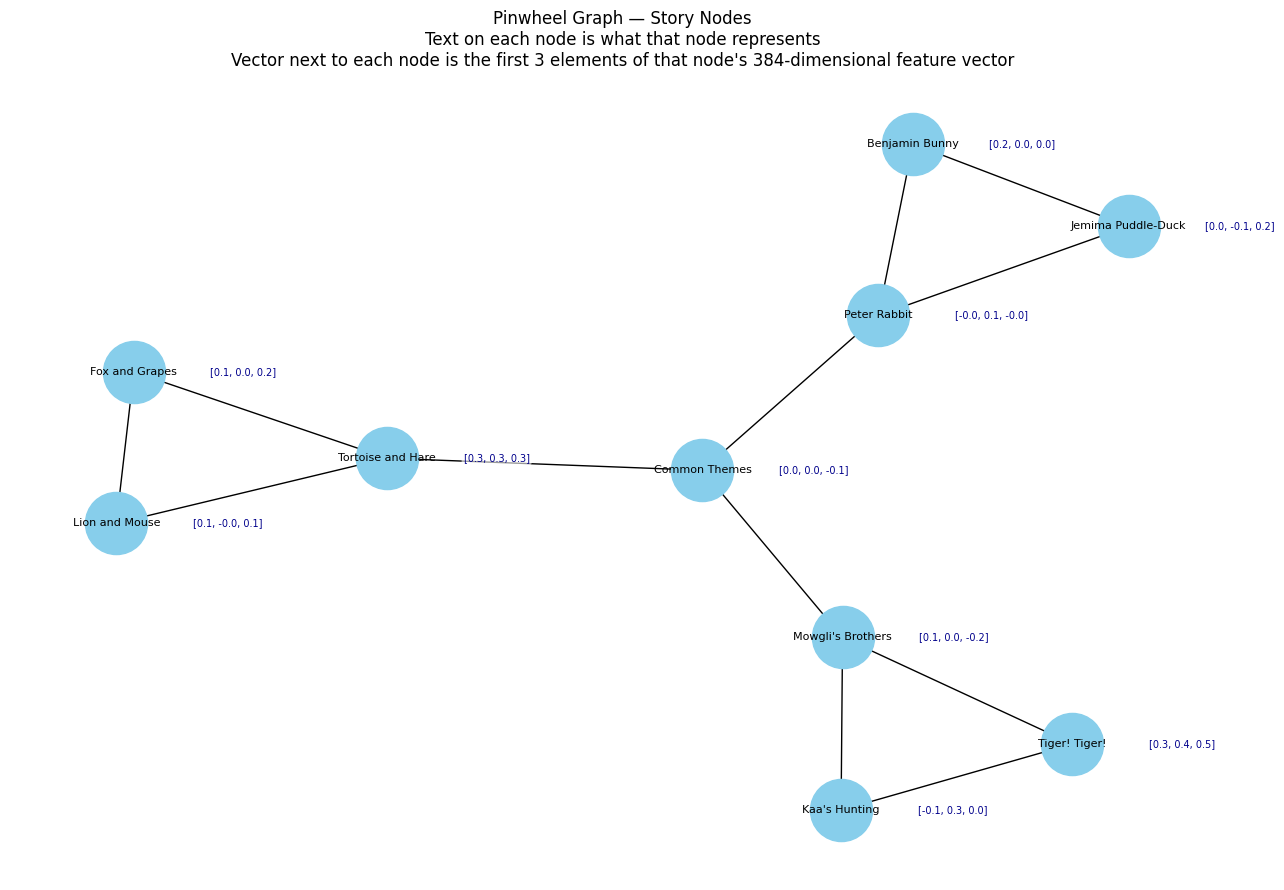

In [26]:
############
## Cell 3 ##
############

import networkx as nx
from matplotlib import pyplot as plt

# Create the graph
G = nx.Graph()
G.add_nodes_from(range(10))
G.add_edges_from([
    (1,2), (1,3), (2,3),
    (4,5), (4,6), (5,6),
    (7,8), (7,9), (8,9),
    (1,0), (4,0), (7,0)
])

# Label nodes with story name
# Node mapping: [0] is summary, [1-3] Potter, [4-6] Aesop, [7-9] Kipling
node_map = {
    0: "Common Themes",   # summary (last row)
    1: "Peter Rabbit", 2: "Benjamin Bunny", 3: "Jemima Puddle-Duck",  # Beatrix Potter
    4: "Tortoise and Hare", 5: "Fox and Grapes", 6: "Lion and Mouse",  # Aesop's Fables
    7: "Mowgli's Brothers", 8: "Kaa's Hunting", 9: "Tiger! Tiger!",  # Rudyard Kipling
}

for i, node in enumerate(G.nodes()):
    G.nodes[node]["node_label"] = node_map[i]

print(f"Node 1's label is '{G.nodes[1]['node_label']}'")

# Match graph node ids to the corresponding row in node_features
feature_map = {
    0: 9,   # summary (last row)
    1: 0, 2: 1, 3: 2,  # Beatrix Potter
    4: 6, 5: 7, 6: 8,  # Aesop's Fables
    7: 3, 8: 4, 9: 5   # Rudyard Kipling
}

# Build text for first three feature values (rounded to one decimal)
vector_labels = {
    node: (
        f"[{node_features[feature_map[node]][0]:.1f}, "
        f"{node_features[feature_map[node]][1]:.1f}, "
        f"{node_features[feature_map[node]][2]:.1f}]"
    )
    for node in G.nodes()
}

# Draw the pinwheel graph with story labels and vector snippets
pos = nx.nx_pydot.graphviz_layout(G, prog="neato")
plt.figure(figsize=(13, 9))
nx.draw_networkx(G,
                 pos=pos,
                 labels=node_map,
                 node_color="skyblue",
                 node_size=2000,
                 font_size=8,
                 font_color="black")

# Put the first three vector elements next to each node
for node, (x, y) in pos.items():
    plt.text(x + 20, y,
             vector_labels[node],
             ha="left",
             va="center",
             fontsize=7,
             color="darkblue",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"))

plt.title(
    "Pinwheel Graph — Story Nodes\n"
    "Text on each node is what that node represents\n"
    "Vector next to each node is the first 3 elements of that node's 384-dimensional feature vector"
)
plt.axis("off")
plt.tight_layout()
plt.show()

#### 6.4 Attach Feature Vectors to the Networkx Representation of Nodes

The code assigns each graph node its 384-dimensional sentence-transformer embedding by writing it into the node's attribute dictionary under the key `"feature"`.

The CSV rows and the graph node indices are **not in the same order**, so an explicit `feature_map` is needed to translate each graph node index into the correct row index of the `node_features` array:

| Graph node | Story | CSV row (feature_map value) |
|---|---|---|
| 0 | Common Themes | 9 |
| 1–3 | Beatrix Potter | 0–2 |
| 4–6 | Aesop's Fables | 6–8 |
| 7–9 | Rudyard Kipling | 3–5 |

After this cell, every node in `G` carries both a human-readable label (`"node_label"`) and a 384-dimensional numerical feature vector (`"feature"`). These two attributes together represent the "what" and the "where" of each node: the label identifies which story it is, and the embedding captures the semantic content of that story's description.

In [27]:
############
## Cell 4 ##
############

# Assign embeddings to nodes
# Node mapping: [0] is summary, [1-3] Potter, [4-6] Aesop, [7-9] Kipling
feature_map = {
    0: 9,   # summary (last row)
    1: 0, 2: 1, 3: 2,  # Beatrix Potter
    4: 6, 5: 7, 6: 8,  # Aesop's Fables
    7: 3, 8: 4, 9: 5   # Rudyard Kipling
}

# Assign each graph node an embedding attribute
for node, idx in feature_map.items():
    G.nodes[node]["feature"] =node_features[idx]

# Inspect node 1's vector
print(f"node 1's feature vector is:\n{G.nodes[1]["feature"]}")

node 1's feature vector is:
[-0.00942474  0.08561928 -0.02222093  0.0206964  -0.2597677  -0.07843472
  0.22576566 -0.41814816  0.37197056  0.1893857   0.20534661  0.16877475
  0.07024492  0.13838132 -0.37497061  0.29595754 -0.49982408 -0.02146331
 -0.03790269 -0.0538012  -0.10715246  0.07044859  0.3055854  -0.20260125
 -0.18777846  0.11627216  0.07965986 -0.14293866 -0.01645887 -0.20721982
 -0.04354618  0.11411875  0.10128494 -0.2895517   0.11491041  0.2846704
 -0.20954518 -0.02741113  0.5035257   0.16052498  0.35871327  0.12208454
  0.35720056 -0.18541965 -0.34033316  0.12989613 -0.21295063  0.19034082
 -0.14056101  0.12240677 -0.19863926 -0.06602473 -0.2117502  -0.1600146
  0.18668558 -0.00260298 -0.08679471 -0.24880603 -0.09348973 -0.08824314
  0.08826852  0.14857909  0.18508339  0.20064731  0.2009621   0.05488067
 -0.5501293  -0.12629011  0.05349026  0.04473858 -0.31169263  0.2731291
  0.04239007  0.08209363 -0.1443588   0.06808186 -0.18634552 -0.17253937
 -0.0932823  -0.08490135 -

---

### 7. Evaluating the Nodes Graph and Implementing a GCN

In this section, we will move from graph theory concepts to a full, hands-on GCN workflow in PyTorch Geometric (PyG). The goal is to understand how graph data becomes model-ready tensors, how PyG organizes those tensors into graph objects, and how we can train a neural network to learn useful node representations.

We will walk through the complete pipeline:


1. Tensors and graph data representation

   We will review how node features, edge indices, labels, and masks are stored as PyTorch tensors.

2. Core PyG objects

   We will build and inspect Data objects (and related structures) to see how PyG packages graph inputs.

3. Defining a GCN model

   We will specify a simple GCN architecture using PyG layers and discuss what each layer is doing mathematically and intuitively.

4. Training and evaluation

   We will implement a standard training loop with loss, optimizer steps, and basic performance tracking.

5. Using learned embeddings

   We will extract node embeddings from hidden layers and show how they can be used for downstream analysis and visualization. 

By the end of Section 7, you should be able to instantiate, train, and interpret a basic GCN in PyG, and understand how to extend this workflow to richer graph learning tasks.



In addition to PyTorch Geometric, other Python frameworks that can be used to implement GCNs include DGL (Deep Graph Library), Spektral, StellarGraph, and TensorFlow GNN.


#### 7.1 Understanding and Using Tensors in PyTorch

Before we use PyTorch Geometric to create and train a GCN, we need one core dependency: **PyTorch** (imported as `torch`). PyTorch is the module that gives us tensor objects and numerical operations for machine learning.

**Install the core tensor module**
If PyTorch is not installed, install it first:
```bash
pip install torch torchvision torchaudio
pip install torch-geometric
```
In this section, the key package is `torch`. The `torchvision` and `torchaudio` packages are common companions, but for graph learning we mainly need `torch` plus `torch-geometric` in the next subsection.

**What does `torch` do?**
At a high level, `torch` provides:
- tensor data structures,
- fast numerical operations on tensors,
- automatic differentiation (needed for training neural networks),
- optional hardware acceleration (CPU, GPU, and Apple Silicon backends when configured).
For now, we are using the simplest part: storing node features as tensors.

**What is a tensor?**
A tensor is a numerical array with a shape (dimensions):
- Scalar: rank-0 tensor, shape `[]`
- Vector: rank-1 tensor, shape `[d]`
- Matrix: rank-2 tensor, shape `[n, d]`
In this notebook:
- each node feature vector is a rank-1 tensor,
- stacking all node vectors gives the feature matrix $X$, a rank-2 tensor.
If there are `num_nodes` nodes and each node has `feature_dim` features, then

$$
X \in \mathbb{R}^{\text{num\_nodes} \times \text{feature\_dim}}.
$$

In the story graph example, each node has a 384-dimensional transformer embedding, so each node starts as a vector of shape `[384]`, and all node features together form a matrix of shape `[num_nodes, 384]`.

**How we will use tensors in Section 7**
We will do one simple, practical conversion:
1. take each node's existing feature vector,
2. convert it to a `torch.tensor` (float type),
3. later stack these vectors into the matrix $X$ used by the GCN.
So conceptually, this subsection is just preparing the input feature tensor representation before we build PyG objects and define the model.

In [29]:
############
## Cell 5 ##
############

## Code written using copilot, with some manual cleanup and comments added by me.

import torch

print("Step 1: Inspect one raw feature vector before conversion.")
example_node = 1
print(f"\tNode {example_node} raw feature type: {type(G.nodes[example_node]['feature'])}")
print(f"\tNode {example_node} raw feature length: {len(G.nodes[example_node]['feature'])}")
print(f"\tNode {example_node} first 5 raw values: {G.nodes[example_node]['feature'][:5]}")

print("\nStep 2: Convert each node feature vector to a torch tensor.")
feature_dims = {len(G.nodes[node]['feature']) for node in G.nodes}
if len(feature_dims) != 1:
    raise ValueError(f"Inconsistent feature lengths across nodes: {sorted(feature_dims)}")
feature_dim = feature_dims.pop()

for node in G.nodes:
    G.nodes[node]['x'] = torch.tensor(G.nodes[node]['feature'], dtype=torch.float32)
print(f"\tConverted tensors for {G.number_of_nodes()} nodes.")
print(f"\tExpected tensor shape per node: ({feature_dim},)")
print(f"\tTensor dtype used: {G.nodes[example_node]['x'].dtype}")

print("\nStep 3: Inspect one converted tensor.")
print(f"\tNode {example_node} tensor shape: {tuple(G.nodes[example_node]['x'].shape)}")
print(f"\tNode {example_node} first 5 tensor values: {G.nodes[example_node]['x'][:5]}")

print("\nOptional check: stack all node tensors into one feature matrix X.")
X_preview = torch.stack([G.nodes[node]['x'] for node in G.nodes])
print(f"\tX shape: {tuple(X_preview.shape)}  # (num_nodes, feature_dim)")


Step 1: Inspect one raw feature vector before conversion.
	Node 1 raw feature type: <class 'numpy.ndarray'>
	Node 1 raw feature length: 384
	Node 1 first 5 raw values: [-0.00942474  0.08561928 -0.02222093  0.0206964  -0.2597677 ]

Step 2: Convert each node feature vector to a torch tensor.
	Converted tensors for 10 nodes.
	Expected tensor shape per node: (384,)
	Tensor dtype used: torch.float32

Step 3: Inspect one converted tensor.
	Node 1 tensor shape: (384,)
	Node 1 first 5 tensor values: tensor([-0.0094,  0.0856, -0.0222,  0.0207, -0.2598])

Optional check: stack all node tensors into one feature matrix X.
	X shape: (10, 384)  # (num_nodes, feature_dim)


#### 7.2 Understanding PyTorch Geometric (PyG) Objects

PyTorch Geometric (PyG) is a graph deep-learning library built on top of PyTorch. Its central data structure is usually a `Data` object, which packages the information needed for a graph-learning task into one place. Since the objects called `Data` appear in other contexts (e.g., pandas), I'll try to follow the practice of calling PyTorch Geometric Objects **PyG Objects**.

A useful way to think about a PyG object is that it stores the same ingredients we have already been working with, but in a format designed for graph neural networks. For node-level tasks, the most important ingredients are:

- the graph structure,
- the node feature matrix,
- and, in many applications, labels, masks, or other metadata (discussed more in subsequent parts of the class).

For this notebook, the two most important PyG attributes are:

- `data.edge_index`: a representation of the graph,
- `data.x`: a representation of the node feature matrix.

A few other useful attributes often include:

- `data.num_nodes`: the number of nodes in the graph,
- `data.y`: labels or targets,
- `data.train_mask`, `data.val_mask`, `data.test_mask`: Boolean masks that identify which nodes belong to which split.

| Attribute | What it stores | Format |
| --- | --- | --- |
| `data.edge_index` | The graph structure as an edge list | A PyTorch tensor of shape `[2, num_edges]`, usually with integer node indices |
| `data.x` | The node feature matrix | A PyTorch tensor of shape `[num_nodes, num_node_features]` |
| `data.num_nodes` | The number of nodes in the graph | An integer scalar |
| `data.y` | Labels or targets for the learning task | A PyTorch tensor; the shape depends on the task |
| `data.train_mask`, `data.val_mask`, `data.test_mask` | Which nodes belong to the training, validation, and test splits | Boolean PyTorch tensors, often of shape `[num_nodes]` |

We will introduce these ideas one piece at a time:

- **7.2.1** shows how the graph structure is stored,
- **7.2.2** shows how node features are stored.

#### 7.2.1 Storing the Graph in the PyG Object

The first thing a PyG object must store is the graph structure: which nodes are connected to which other nodes. In PyG, this connectivity is usually stored in the attribute `edge_index`.

`edge_index` is a tensor of shape `[2, num_edges]`:

- each column represents one edge,
- the first row stores source-node indices,
- the second row stores target-node indices.

So if one column of `edge_index` is `[1, 4]`, that means there is an edge from node 1 to node 4.

For undirected graphs, PyG **commonly stores both directions of an edge**. So an undirected edge between nodes 1 and 4 may appear as two columns: `[1, 4]` and `[4, 1]`.

In the next code cell, we convert the story graph from NetworkX into a PyG `Data` object and then inspect `edge_index` and `num_nodes` so you can see exactly how the graph structure is stored.

In [32]:
############
## Cell 6 ##
############

from torch_geometric.data import Data as PygData
from torch_geometric.utils import from_networkx

print("Step 1: Build a NetworkX graph that contains only the graph structure.")
structure_only_graph = nx.Graph()
structure_only_graph.add_nodes_from(G.nodes())
structure_only_graph.add_edges_from(G.edges())
print("\tThis avoids converting node attributes we do not need yet.")

print("\nStep 2: Convert the structure-only graph into a PyG Data object.")
data: PygData = from_networkx(structure_only_graph)
print(f"\tObject type: {type(data)}")

print("\nStep 3: Inspect the basic graph information stored in the PyG object.")
print(f"\tNumber of nodes: {data.num_nodes}")
print(f"\tedge_index shape: {tuple(data.edge_index.shape)}")
print("\tInterpretation: 2 rows = [source nodes; target nodes], columns = individual edges")

print("\nStep 4: Look at the first few stored edges.")
num_edges_to_show = min(6, data.edge_index.shape[1])
edge_preview = data.edge_index[:, :num_edges_to_show]
print(edge_preview)

print("\nStep 5: Translate those columns into readable source -> target edges.")
for column_index in range(num_edges_to_show):
    source_node = int(edge_preview[0, column_index])
    target_node = int(edge_preview[1, column_index])
    print(f"\tColumn {column_index}: {source_node} -> {target_node}")

print("\nStep 6: Compare PyG edge storage with the original NetworkX graph.")
print(f"\tNetworkX reports {G.number_of_edges()} undirected edges.")
print(f"\tPyG stores {data.edge_index.shape[1]} directed edge entries.")
print("\tFor an undirected graph, PyG often stores both directions of each edge.")

Step 1: Build a NetworkX graph that contains only the graph structure.
	This avoids converting node attributes we do not need yet.

Step 2: Convert the structure-only graph into a PyG Data object.
	Object type: <class 'torch_geometric.data.data.Data'>

Step 3: Inspect the basic graph information stored in the PyG object.
	Number of nodes: 10
	edge_index shape: (2, 24)
	Interpretation: 2 rows = [source nodes; target nodes], columns = individual edges

Step 4: Look at the first few stored edges.
tensor([[0, 0, 0, 1, 1, 1],
        [1, 4, 7, 0, 2, 3]])

Step 5: Translate those columns into readable source -> target edges.
	Column 0: 0 -> 1
	Column 1: 0 -> 4
	Column 2: 0 -> 7
	Column 3: 1 -> 0
	Column 4: 1 -> 2
	Column 5: 1 -> 3

Step 6: Compare PyG edge storage with the original NetworkX graph.
	NetworkX reports 12 undirected edges.
	PyG stores 24 directed edge entries.
	For an undirected graph, PyG often stores both directions of each edge.


#### 7.2.2 Storing Node Features in `data.x`

A GCN takes two inputs and produces one output:

| Symbol | Role | PyG attribute |
|--------|------|---------------|
| **X** | Feature matrix — one row per node, one column per input feature | `data.x` |
| **A** | Graph structure — which nodes are connected | `data.edge_index` |
| **y** | Target labels (for supervised tasks) | `data.y` |

We already stored **A** in `data.edge_index` in section 7.2.1. Now we need to store **X** in `data.x`.

**What is `data.x`?**

`data.x` is a 2-D tensor of shape $[n, f]$, where:
- $n$ is the number of nodes in the graph, and
- $f$ is the number of input features per node.

Every row of `data.x` is the feature vector for one node. In our story graph, each node's feature vector is the 384-dimensional sentence-embedding of the story it corresponds to, so `data.x` will have shape $[10, 384]$.

**Two requirements to keep in mind:**

1. **`data.x` must be a PyTorch float tensor.** PyG's convolutional layers (like `GCNConv`) perform matrix multiplications internally, so the feature matrix must be a tensor — a NumPy array or a Python list will not work.

2. **The number of rows in `data.x` must equal the number of nodes in `data.edge_index`.** The graph convolution step looks up features by node index. If `data.edge_index` references node indices 0–9 but `data.x` only has 8 rows, PyG will fail when it tries to retrieve features for nodes 8 and 9.

In the next cell, we collect the pre-computed feature tensors from the NetworkX graph (one per node), stack them in node-index order to form the matrix $X$, and then verify that the row count matches the node count.

In [33]:
############
## Cell 7 ##
############

# Step 1: Collect the pre-computed feature tensor for every node.
#   Each node in G already carries a torch float32 tensor stored under the key 'x'.
#   We list them in node-index order so that row i of data.x corresponds to node i.
print("Step 1: Collect the pre-computed feature tensor for every node.")
feature_list = [G.nodes[node]['x'] for node in G.nodes]
print(f"\tCollected {len(feature_list)} tensors, one per node.")
print(f"\tEach tensor has shape : {tuple(feature_list[0].shape)}")
print(f"\tTensor dtype          : {feature_list[0].dtype}  <-- must be a float tensor for GCNConv")

# Step 2: Stack the tensors row-by-row to form the N x F feature matrix X.
#   torch.stack() turns a list of 1-D tensors of size F into a 2-D tensor of shape [N, F].
print("\nStep 2: Stack the tensors into the feature matrix X and store it in data.x.")
data.x = torch.stack(feature_list)
print(f"\tdata.x shape: {tuple(data.x.shape)}")
print(f"\tInterpretation: {data.x.shape[0]} rows (nodes)  x  {data.x.shape[1]} columns (features per node)")

# Step 3: Verify alignment between the feature matrix and the graph structure.
#   data.num_nodes is derived from edge_index; data.x.shape[0] must match it.
print("\nStep 3: Verify that data.x is aligned with data.edge_index.")
print(f"\tdata.num_nodes  = {data.num_nodes}   <- total nodes implied by edge_index")
print(f"\tdata.x.shape[0] = {data.x.shape[0]}   <- rows in the feature matrix")
assert data.x.shape[0] == data.num_nodes, (
    f"Mismatch: data.x has {data.x.shape[0]} rows but the graph has {data.num_nodes} nodes."
)
print("\tAlignment check passed: every node has exactly one feature row in data.x.")

Step 1: Collect the pre-computed feature tensor for every node.
	Collected 10 tensors, one per node.
	Each tensor has shape : (384,)
	Tensor dtype          : torch.float32  <-- must be a float tensor for GCNConv

Step 2: Stack the tensors into the feature matrix X and store it in data.x.
	data.x shape: (10, 384)
	Interpretation: 10 rows (nodes)  x  384 columns (features per node)

Step 3: Verify that data.x is aligned with data.edge_index.
	data.num_nodes  = 10   <- total nodes implied by edge_index
	data.x.shape[0] = 10   <- rows in the feature matrix
	Alignment check passed: every node has exactly one feature row in data.x.


### 7.3 The Building Blocks of a GCN

In PyTorch (and PyG), a GCN is defined as a Python class that inherits from `torch.nn.Module`. That class always has at least two methods: `__init__` and `forward`. A full, trainable model would typically also include a **loss function**, an **optimizer**, and a **training loop** — but we will come back to those later. For now we focus on the two core methods.

| Method | What it defines |
|--------|-----------------|
| `__init__` | The **architecture**: how many layers exist, what type each layer is, and the input/output dimensions of each layer. |
| `forward` | The **computation**: how data actually flows through those layers when you call the model — which layer runs first, what activation functions are applied between layers, and what the final output is. |

**Other parts of a full GCN (not used in this section):**

- **Loss function** — measures how wrong the model's predictions are. Common choices for node classification: cross-entropy. For embedding quality: contrastive loss or mean-squared error.
- **Optimizer** — the algorithm that updates the model weights to reduce the loss. Typical choice: Adam or SGD.
- **Training loop** — repeatedly runs the forward pass, computes the loss, and calls the optimizer to nudge the weights in the right direction.

Because we have no labels to train against yet, we are going to run the model with its **randomly initialized weights** just to see what kind of node embeddings a GCN produces before any learning happens. This is a useful sanity check: even untrained, a GCN already produces different embeddings for nodes that occupy different structural positions in the graph.

#### 7.3.1 Specifying the Architecture in `__init__`

`__init__` is where you declare every learnable layer the model will use. For a GCN, each layer is a `GCNConv` object from PyG. A single `GCNConv(in_channels, out_channels)` layer:

1. **Aggregates** the feature vectors of each node's neighbors (using the normalized adjacency we derived earlier in this notebook).
2. **Transforms** the result with a learned weight matrix of shape $[in\_channels, out\_channels]$.

By stacking multiple `GCNConv` layers you create a deeper model. A node's embedding in layer $k$ reflects information from nodes up to $k$ hops away — one extra hop of context per layer.

**Dimension choices for our story graph:**

```
Input layer   :  384 features  (the MiniLM sentence-embedding dimension)
Hidden layer 1:  128 features  (first compression step)
Hidden layer 2:   64 features  (second compression step)
Output layer  :   32 features  (final node embedding size)
```

Each number is a design decision, which means that there is no single correct value. The general principle is to gradually compress from the raw feature dimension down to a smaller embedding that can be used for downstream tasks like clustering or classification.

In the code cell below, the class `ThreeLayerGCN` accepts these four numbers as constructor arguments (`in_channels`, `hidden_channels_1`, `hidden_channels_2`, `out_channels`) so the same class can be reused for different architectures without rewriting it.

In [34]:
############
## Cell 8 ##
############

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class ThreeLayerGCN(nn.Module):
    """
    A three-layer Graph Convolutional Network.

    Architecture (parameterized so class can be reused for any dimension choice):
        Input  → GCNConv(in_channels,       hidden_channels_1)  → ReLU
                 GCNConv(hidden_channels_1,  hidden_channels_2)  → ReLU
                 GCNConv(hidden_channels_2,  out_channels)       → (no activation; raw embedding)

    Parameters
    ----------
    in_channels : int
        Number of input features per node (e.g. 384 for MiniLM embeddings).
    hidden_channels_1 : int
        Width of the first hidden layer (first compression step).
    hidden_channels_2 : int
        Width of the second hidden layer (second compression step).
    out_channels : int
        Width of the output layer — the final embedding dimension for each node.
    """
    def __init__(
        self,
        in_channels: int,
        hidden_channels_1: int,
        hidden_channels_2: int,
        out_channels: int,
    ):
        super().__init__()

        # Layer 1: aggregates raw input features from each node's neighbors.
        #          Transforms from in_channels → hidden_channels_1.
        self.hidden1 = GCNConv(in_channels, hidden_channels_1)

        # Layer 2: aggregates the layer-1 representations from each node's neighbors.
        #          Transforms from hidden_channels_1 → hidden_channels_2.
        self.hidden2 = GCNConv(hidden_channels_1, hidden_channels_2)

        # Layer 3 (output): aggregates the layer-2 representations.
        #          Transforms from hidden_channels_2 → out_channels.
        #          No activation is applied here; the raw output is the node embedding.
        self.output = GCNConv(hidden_channels_2, out_channels)

    def forward(self, data: PygData) -> torch.Tensor:
        # Unpack the two inputs the GCN needs from the PyG Data object.
        x, edge_index = data.x, data.edge_index

        # Layer 1: neighborhood aggregation + linear transform, then ReLU.
        h1 = self.hidden1(x, edge_index)        # shape: [N, hidden_channels_1]
        h1 = F.relu(h1)                          # zero out negative values

        # Layer 2: same pattern — aggregate, transform, activate.
        h2 = self.hidden2(h1, edge_index)        # shape: [N, hidden_channels_2]
        h2 = F.relu(h2)

        # Output layer: aggregate and transform; no activation.
        out = self.output(h2, edge_index)        # shape: [N, out_channels]
        return out

print("ThreeLayerGCN class defined.")

ThreeLayerGCN class defined.


#### 7.3.2 What the Forward Pass Does

The `forward` method is where the matrix equations from sections 3 and 4 actually run. Recall the general single-layer update we derived there:

$$H^{(\ell+1)} = \phi\!\left(\tilde{D}^{-1/2}\,\tilde{A}\,\tilde{D}^{-1/2}\;H^{(\ell)}\;W^{(\ell)}\right)$$

Every symbol in that equation has a concrete counterpart in the code:

| Symbol | What it means | Where it comes from in the code |
|--------|---------------|---------------------------------|
| $H^{(0)} = X$ | Node feature matrix — one row per node | `data.x` (assembled in section 7.2.2) |
| $\tilde{A} = A + I$ | Adjacency matrix with self-loops added | Derived by `GCNConv` from `data.edge_index` |
| $\tilde{D}$ | Degree matrix of $\tilde{A}$ | Computed internally by `GCNConv` |
| $W^{(\ell)}$ | Learned weight matrix for layer $\ell$ | Stored inside `self.hidden1`, `self.hidden2`, `self.output` |
| $\phi$ | Activation function | `F.relu(...)` applied after each hidden layer |
| $H^{(\ell)}$ | Output of layer $\ell$ — passes to the next layer | Python variables `h1`, `h2`, `out` |

**Tracing the code line by line:**

```python
x, edge_index = data.x, data.edge_index
```
Unpacks $H^{(0)} = X$ and the graph structure used to build $\tilde{A}$ and $\tilde{D}$.

---

```python
h1 = self.hidden1(x, edge_index)   # GCNConv: propagate + transform
h1 = F.relu(h1)                    # activation φ
```
This is layer 1 of the recurrence:

$$H^{(1)} = \phi\!\left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\;H^{(0)}\;W^{(0)}\right)$$

$W^{(0)}$ has shape $[384 \times 128]$, so $H^{(1)}$ has shape $[N, 128]$.  
Each node's row now carries a ReLU-activated summary of its own features **and** those of its 1-hop neighbors.

---

```python
h2 = self.hidden2(h1, edge_index)  # GCNConv: propagate + transform
h2 = F.relu(h2)                    # activation φ
```
Layer 2 of the recurrence:

$$H^{(2)} = \phi\!\left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\;H^{(1)}\;W^{(1)}\right)$$

$W^{(1)}$ has shape $[128 \times 64]$, so $H^{(2)}$ has shape $[N, 64]$.  
Because layer 2's *input* already incorporates 1-hop neighborhood information, layer 2's output effectively reflects 2-hop neighborhoods from the original graph.

---

```python
out = self.output(h2, edge_index)  # GCNConv: propagate + transform, NO activation
```
Output layer:

$$H^{(3)} = \tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\;H^{(2)}\;W^{(2)}$$

$W^{(2)}$ has shape $[64 \times 32]$, so $H^{(3)}$ has shape $[N, 32]$.  
Notice there is **no $\phi$ wrapping this layer**. As discussed in section 4.4, we omit activation on the output layer so negative values are preserved in the final embedding, not clipped to zero before the embedding is used downstream.

#### 7.3.3 Running the Model Without Training

Before we add a training loop, it is instructive to run the GCN with its **default (random) weights** and observe what comes out. This forward-pass-only run answers the question: *what does the graph structure alone contribute to the embeddings, before any learning has taken place?*

**What to expect:**

- The weight matrices $W^{(0)}, W^{(1)}, W^{(2)}$ are initialized randomly (PyTorch uses Kaiming uniform initialization by default for `GCNConv`).
- Because the graph structure is baked into every aggregation step, nodes that are topologically similar — connected to similar neighbors — will already produce more similar output vectors than nodes that are far apart in the graph.
- But since the weights are random, there is no guarantee the embeddings are *useful* for any particular task. They simply reflect the untrained aggregation of randomly transformed features.

---

**What is a computation graph?**

Every time PyTorch runs a forward pass, it silently builds a second data structure alongside the numeric output: a **computation graph**. This graph records every operation that was applied to every tensor (the multiplications, additions, and activations) as a directed graph of nodes and edges. The leaf nodes of this graph are the learnable weight matrices $W^{(0)}, W^{(1)}, W^{(2)}$.

The computation graph is the mechanism that makes **training** possible. When we eventually train the network, we will:

1. Run the forward pass (compute predictions).
2. Compute a loss (measure how wrong the predictions are).
3. Call `loss.backward()` — PyTorch walks **backward** through the computation graph using the chain rule to compute $\partial \text{loss} / \partial W^{(\ell)}$ for every weight matrix.
4. Call the optimizer, which uses those gradients to nudge the weights in the direction that reduces the loss.

That walk backward through the computation graph is **gradient descent** (or more precisely, back-propagation to compute the gradients that gradient descent then uses).

---

**What `torch.no_grad()` means**

`torch.no_grad()` is Python's way of saying: *do not build a computation graph during this forward pass* — in other words, **no gradient descent will be used to update any weights here**.

Skipping the computation graph has two practical benefits:
- **Memory**: storing the graph for a full forward pass can be expensive; not building it frees that memory.
- **Speed**: a small but real overhead is removed.

`no_grad` is the standard context manager to use whenever you run a model without intending to train it. That includes **inference** — the phase after training is finished, where you apply the trained model to new data to get predictions or embeddings — as well as exploratory runs like the one we do here, where we just want to see what the model produces before any training has begun.

---

The output of the forward pass is a tensor of shape $[N, 32]$: one 32-dimensional embedding vector per node. This is the final $H^{(3)}$ from the layer recurrence — the output layer's version of the node feature matrix, where each row is one node's position in the 32-dimensional learned space. Those 32 numbers are what get passed to downstream tasks like clustering or visualization.

In [36]:
############
## Cell 9 ##
############

# Step 1: Choose dimensions that match what we built in sections 7.2 and 7.3.1.
in_dim       = data.x.shape[1]  # 384  — MiniLM sentence-embedding dimension
hidden_dim_1 = 128              # first compression:  384 → 128
hidden_dim_2 = 64               # second compression: 128 → 64
out_dim      = 32               # final embedding:     64 → 32

print("Step 1: Define the architecture.")
print(f"\tInput features    : {in_dim}")
print(f"\tHidden layer 1    : {hidden_dim_1}")
print(f"\tHidden layer 2    : {hidden_dim_2}")
print(f"\tOutput embedding  : {out_dim}")

# Step 2: Instantiate the model with those dimensions.
#   model.eval() puts the model in inference mode (important when layers like
#   Dropout or BatchNorm are present — they behave differently during training).
gcn = ThreeLayerGCN(in_dim, hidden_dim_1, hidden_dim_2, out_dim)
gcn.eval()
print(f"\nStep 2: Model instantiated with randomly initialized weights.")
print(gcn)

# Step 3: Run a forward pass without tracking gradients.
#   torch.no_grad() prevents PyTorch from building the computation graph,
#   which saves memory and is the standard practice for inference.
print("\nStep 3: Run the untrained forward pass.")
with torch.no_grad():
    node_embeddings = gcn(data)  # shape: [N, out_dim]

print(f"\tOutput shape: {tuple(node_embeddings.shape)}")
print(f"\tInterpretation: {node_embeddings.shape[0]} nodes × {node_embeddings.shape[1]} embedding dimensions")

# Step 4: Peek at the first two embedding vectors.
print("\nStep 4: Preview the first two node embeddings (random weights, no training).")
for i in range(2):
    label = node_map.get(i, f"node {i}")
    vec_preview = node_embeddings[i, :6].tolist()
    print(f"\t{label}: [{', '.join(f'{v:.3f}' for v in vec_preview)}, ...]")

Step 1: Define the architecture.
	Input features    : 384
	Hidden layer 1    : 128
	Hidden layer 2    : 64
	Output embedding  : 32

Step 2: Model instantiated with randomly initialized weights.
ThreeLayerGCN(
  (hidden1): GCNConv(384, 128)
  (hidden2): GCNConv(128, 64)
  (output): GCNConv(64, 32)
)

Step 3: Run the untrained forward pass.
	Output shape: (10, 32)
	Interpretation: 10 nodes × 32 embedding dimensions

Step 4: Preview the first two node embeddings (random weights, no training).
	Common Themes: [0.172, 0.014, 0.147, -0.012, 0.180, -0.069, ...]
	Peter Rabbit: [0.152, -0.012, 0.157, 0.062, 0.230, -0.105, ...]


---

### 8. Using the Embedding to Partition Nodes

We now have `node_embeddings`: a $[10 \times 32]$ tensor where each row is a 32-dimensional vector representing one story node in the GCN's learned space.

This is the third time in this course we have used an embedding to partition a graph. The earlier two are worth recalling:

| Method | What drives the partition |
|--------|--------------------------|
| **Spectral embedding** (Laplacian eigenvectors) | Graph structure only — which nodes are connected to which |
| **DeepWalk / Node2Vec** | Graph structure only — co-occurrence patterns along random walks |
| **GCN embedding** (this section) | Graph structure **and** node features — the normalized adjacency aggregation is guided by the sentence-embedding content of each node |

The key difference is the last row. Both spectral methods and random-walk methods are blind to what is written on the nodes; they only see edges. The GCN aggregation step folds the sentence-embedding content of each node's neighbors into its representation, so nodes that are both *structurally close* (i.e., regular and structural equivalence) and *semantically similar* (i.e., have similar features) end up near each other in embedding space.

In this section we will:

1. **Compress** the 32-dimensional embeddings to 2D with t-SNE to make them visible (section 8.1).
2. **Cluster** the nodes in the full 32-dimensional space using K-means and display the result on the original graph (section 8.2).
3. **Interpret** why a sensible partition emerged even though the weight matrices were never trained (section 8.3).

#### 8.1 Visualize the Embeddings with t-SNE

`node_embeddings` has shape $[10, 32]$ — 32 dimensions per node. We cannot directly plot a 32-dimensional space, so we first compress it to 2D using **t-SNE** (t-distributed Stochastic Neighbor Embedding).

**What t-SNE does.** t-SNE is a nonlinear dimensionality-reduction technique that places points in 2D so that pairs of points that are nearby in the original high-dimensional space are also nearby in the 2D plot. It optimizes the 2D layout to preserve *local* neighborhood structure — it is especially good at revealing clusters that are well-separated in the original space.

**Why not PCA?** Principal Component Analysis finds the directions of maximum variance and projects onto them, which is a linear operation. Because GCN embeddings can have nonlinear structure (a product of three rounds of ReLU-activated aggregation), t-SNE tends to reveal cluster structure more clearly than PCA for this kind of data.

**An important caveat.** t-SNE is a tool for visualization, not for analysis. Distances in the 2D plot are not a reliable measure of distances in the original 32-dimensional space, and the absolute positions and orientations of clusters are arbitrary. We use the 2D plot only to get a visual impression of which nodes are close together. The actual clustering in section 8.2 is done in the original 32-dimensional space.

**Code note.** `perplexity=5` is a t-SNE hyperparameter that loosely controls how many near-neighbors each point tries to preserve. For a graph with only 10 nodes, a small perplexity (roughly half the number of points) is appropriate; a large perplexity on a small dataset can collapse all points together.

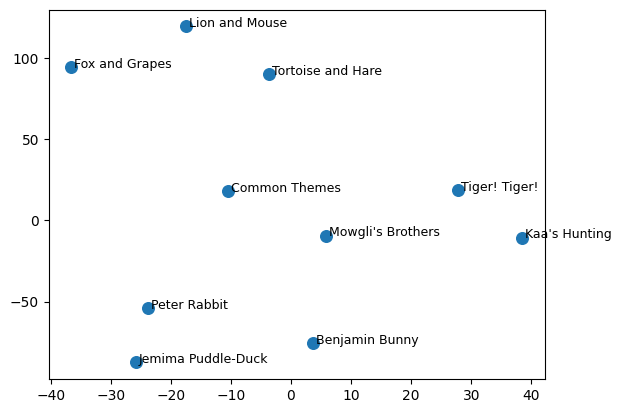

In [ ]:
#############
## Cell 10 ##
#############

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(Z, node_map):
    z = TSNE(
        n_components=2,
        perplexity=5,
        random_state=1234,
        init="pca",
        learning_rate="auto"
    ).fit_transform(Z)
    _ = plt.scatter(z[:, 0], z[:, 1], s=70)
    for i, (x, y) in enumerate(z):
        label = node_map.get(i, str(i))  # fallback to node number if not in map
        plt.text(x + 0.5, y, label, fontsize=9)

visualize(node_embeddings, node_map)

#### 8.2 Find Clusters with K-Means

The t-SNE scatter plot gives a visual impression of groupings, but t-SNE distorts distances. **You should run K-means on the 2D plot coordinates** and expect the same answer as clustering in the original space. We therefore run K-means directly on `node_embeddings`, the full $[10, 32]$ tensor.

**Why K-means here?** K-means partitions points into $k$ groups by minimizing the within-cluster sum of squared distances to each cluster centroid. It is a natural choice when the goal is to find compact, well-separated groups in Euclidean space, which is exactly what we expect from a node-embedding space that aggregated semantically similar stories together.

**Choosing $k = 4$.** The story graph has a pinwheel structure with four spokes: one Beatrix Potter spoke, one Aesop spoke, one Kipling spoke, and the hub node that connects to all of them. With no training signal, setting $k = 4$ is a reasonable guess informed by our knowledge of the data. (In practice you would sweep $k$ and use the *silhouette* score or *elbow plot* to choose.)

**Silhouette score.** The silhouette score summarizes how well each point fits its own cluster versus neighboring clusters. It ranges from $-1$ (wrong cluster) to $+1$ (tight, well-separated clusters). A score near 0 means clusters are overlapping. We print it here as a quick sanity check. A score meaningfully above 0 would indicate that the GCN embeddings pulled story-similar nodes closer together.

**Visualizing on the graph.** After clustering, we draw the original story graph and color each node by its cluster label. This lets us check directly whether the clusters correspond to the story groupings, even though K-means knew nothing about the story labels; it only saw the 32-dimensional embedding vectors.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


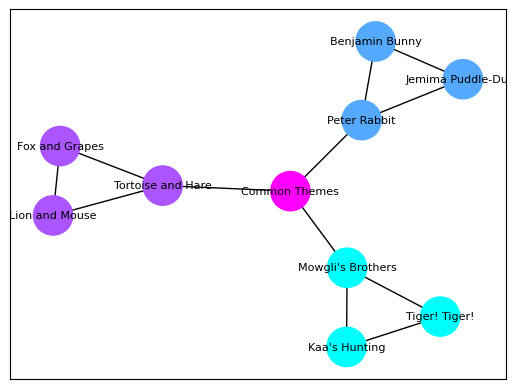

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    init="random",
    n_clusters=4,
    n_init=10,
    random_state=1234
)

# Cluster in higher dimensional space. Use t-SNE only for visualization.
kmeans.fit(node_embeddings)

score = silhouette_score(node_embeddings, kmeans.labels_)
print(f"Silhouette score: {score:.3f}")

nx.draw_networkx(G,
                 #pos=nx.spring_layout(G,seed=0),
                 pos=nx.nx_pydot.graphviz_layout(G, prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 labels=node_map,
                 font_size=8,
                 font_color='black')

#### 8.3 Why This Worked Without Training

The weight matrices were never updated. Rather, they hold their random initialization. And yet the K-means partition likely corresponds reasonably well to the story groups. Why?

**The sentence embeddings already carry cluster structure.** Before the GCN runs, each node's raw feature vector is a 384-dimensional sentence embedding produced by the MiniLM pretrained transformer. Stories from the same author are semantically similar, so the MiniLM embeddings of, say, the three Beatrix Potter stories already sit close together in the 384-dimensional input space. A random linear projection ($W^{(0)}$) of a set of already-close vectors produces another set of close vectors; random projection roughly preserves relative distances.

**Neighborhood aggregation reinforces the structure.** Each GCN layer mixes a node's own features with those of its neighbors. In the pinwheel layout, each story node is connected only to the hub and to the other stories on the same spoke. After one round of aggregation, each story node's representation is a mixture of its own (semantically similar) spoke-neighbors and the hub. After two and three rounds, the spoke stories have absorbed progressively more signal from each other and progressively less from distant spokes. This pushes same-spoke nodes toward each other in embedding space and pushes different-spoke nodes apart.

**Compare to spectral and random-walk methods.** The Laplacian eigenvectors and DeepWalk embeddings also placed same-spoke nodes near each other — but only because of edge connectivity. A node connected to three nodes in a chain looks structurally similar to another node connected to three nodes in a chain, regardless of what those nodes represent. The GCN partition is additionally shaped by the semantic content of the features: two nodes that share an edge but whose feature vectors point in completely different directions would be pulled apart, not together, by the aggregation step. This is the fundamental advantage of GCNs over purely structural methods.